# Contrastive Learning for TE Clustering (V1)

This notebook implements **self-supervised contrastive learning** for DNA transposable element clustering.

## Approach (Option B)
1. Load pretrained V4 hybrid model (CNN + K-mer GNN)
2. Filter to DNA-positive sequences only
3. Replace multi-class head with contrastive projection head
4. Train with NT-Xent loss using RC-based positive pairs
5. Cluster embeddings and visualize with UMAP

## Positive Pair Strategies
- **Sequence ↔ Reverse Complement**: Intrinsic biological invariance
- **Overlapping windows**: Same TE element
- **Augmentations**: Masked motifs, random crops

In [1]:
# ============ Imports ============
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans, HDBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [2]:
# ============ Configuration ============
FASTA_PATH = "../../data/vgp/all_vgp_tes.fa"
LABEL_PATH = "../../data/vgp/20251215-features-tpase"
PREDICTIONS_PATH = "../vgp_model_data_tpase_multi/all_predictions_v3_v4.csv"
V4_CHECKPOINT_PATH = "../vgp_model_data_tpase_multi/hybrid_v4_epoch39.pt"

# Model hyperparameters (must match V4 checkpoint)
FIXED_LENGTH = 5000
KMER_K = 7
KMER_DIM = 2048
KMER_WINDOW = 512
KMER_STRIDE = 256
GNN_HIDDEN = 128
GNN_LAYERS = 3
CNN_WIDTH = 128
MOTIF_KERNELS = (7, 15, 21)
CONTEXT_DILATIONS = (1, 2, 4, 8)
RC_FUSION_MODE = "late"
FUSION_DIM = 256
NUM_HEADS = 4

# Contrastive learning parameters
PROJ_DIM = 128           # Projection head output dimension
TEMPERATURE = 0.1        # NT-Xent temperature
BATCH_SIZE = 32          # Batch size for contrastive learning
EPOCHS = 50              # Training epochs
LR = 1e-4                # Lower LR for fine-tuning
ENCODER_LR_MULT = 0.1    # Encoder LR multiplier

# Filter to DNA+ sequences with high confidence
BINARY_CONF_THRESHOLD = 0.9  # Minimum confidence for binary prediction

def resolve_device(requested=None):
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


## Data Loading Utilities

In [3]:
# ============ Analyze V3/V4 Predictions for Superfamily Selection ============
# Load the full predictions file to understand superfamily distribution

V3V4_PATH = "../vgp_model_data_tpase_multi/all_predictions_v3_v4.csv"
df_pred = pd.read_csv(V3V4_PATH)
print(f"Total sequences: {len(df_pred)}")

# V4 binary predictions
print("\n=== V4 Binary Predictions ===")
print(df_pred['v4_bin_pred'].value_counts())

# V4 DNA+ sequences
dna_pos = df_pred[df_pred['v4_bin_pred'] == 1]
print(f"\nDNA+ sequences: {len(dna_pos)}")

# V4 superfamily distribution for DNA+
print("\n=== V4 Superfamily Distribution (All DNA+) ===")
sf_counts = dna_pos['v4_sf_pred'].value_counts()
print(sf_counts)

# Filter by confidence >= 0.9
high_conf = dna_pos[dna_pos['v4_bin_conf'] >= 0.9]
print(f"\n=== DNA+ with conf >= 0.9: {len(high_conf)} ===")
sf_counts_hc = high_conf['v4_sf_pred'].value_counts()
print(sf_counts_hc)

# Identify rare superfamilies (< 100 sequences at high confidence)
MIN_SAMPLES = 100
rare_sfs = sf_counts_hc[sf_counts_hc < MIN_SAMPLES].index.tolist()
common_sfs = sf_counts_hc[sf_counts_hc >= MIN_SAMPLES].index.tolist()

print(f"\n=== Common superfamilies (>= {MIN_SAMPLES} samples): {len(common_sfs)} ===")
for sf in common_sfs:
    print(f"  {sf}: {sf_counts_hc[sf]}")

print(f"\n=== Rare superfamilies (< {MIN_SAMPLES} samples): {len(rare_sfs)} ===")
for sf in rare_sfs:
    print(f"  {sf}: {sf_counts_hc[sf]}")

# Recommended superfamilies for training
print("\n" + "=" * 60)
print("RECOMMENDATION: Use these superfamilies for contrastive learning:")
print("=" * 60)
total_common = sf_counts_hc[common_sfs].sum()
print(f"Total sequences with common superfamilies: {total_common}")
print(f"Superfamilies to include: {common_sfs}")

Total sequences: 135751

=== V4 Binary Predictions ===
v4_bin_pred
0    111934
1     23817
Name: count, dtype: int64

DNA+ sequences: 23817

=== V4 Superfamily Distribution (All DNA+) ===
v4_sf_pred
DNA/hAT              9955
DNA                  6725
DNA/TcMar-Tc1        2986
DNA/PIF-Harbinger    1412
DNA/PiggyBac         1342
DNA/Academ-1          762
DNA/CMC               635
Name: count, dtype: int64

=== DNA+ with conf >= 0.9: 21980 ===
v4_sf_pred
DNA/hAT              9409
DNA                  5915
DNA/TcMar-Tc1        2807
DNA/PIF-Harbinger    1364
DNA/PiggyBac         1184
DNA/Academ-1          739
DNA/CMC               562
Name: count, dtype: int64

=== Common superfamilies (>= 100 samples): 7 ===
  DNA/hAT: 9409
  DNA: 5915
  DNA/TcMar-Tc1: 2807
  DNA/PIF-Harbinger: 1364
  DNA/PiggyBac: 1184
  DNA/Academ-1: 739
  DNA/CMC: 562

=== Rare superfamilies (< 100 samples): 0 ===

RECOMMENDATION: Use these superfamilies for contrastive learning:
Total sequences with common superfamilie

In [4]:
# ============ FASTA and Label Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


# Valid specific DNA superfamilies (exclude generic 'DNA' label)
# These are the superfamilies from V4 predictions with >= MIN_SAMPLES
VALID_SPECIFIC_SUPERFAMILIES = [
    'DNA/hAT',
    'DNA/TcMar-Tc1', 
    'DNA/PIF-Harbinger',
    'DNA/PiggyBac',
    'DNA/Academ-1',
    'DNA/CMC'
]


def load_dna_positive_sequences(fasta_path, predictions_path, conf_threshold=0.9, 
                                 min_samples_per_sf=100,
                                 exclude_generic_dna=True):
    """
    Load sequences that are predicted as DNA transposase-positive with high confidence.
    Uses V4 model predictions from the CSV file.
    
    Args:
        fasta_path: Path to FASTA file with sequences
        predictions_path: Path to CSV with V4 predictions
        conf_threshold: Minimum confidence threshold for DNA+ prediction
        min_samples_per_sf: Minimum samples per superfamily to include
        exclude_generic_dna: If True, exclude generic 'DNA' label (no specific SF)
    
    Returns:
        headers: List of sequence headers
        sequences: List of DNA sequences
        superfamilies: List of predicted superfamily labels
        confidences: List of binary prediction confidences
    """
    # Load predictions
    df = pd.read_csv(predictions_path)
    print(f"Loaded {len(df)} predictions from CSV")
    
    # Filter to DNA+ with high confidence
    dna_positive = df[
        (df['v4_bin_pred'] == 1) & 
        (df['v4_bin_conf'] >= conf_threshold)
    ].copy()
    
    print(f"DNA+ sequences (V4 conf >= {conf_threshold}): {len(dna_positive)}")
    
    # Show superfamily distribution before filtering
    print("\nSuperfamily distribution before filtering:")
    sf_counts_before = dna_positive['v4_sf_pred'].value_counts()
    for sf, count in sf_counts_before.items():
        print(f"  {sf}: {count}")
    
    # Filter out generic 'DNA' label if requested
    if exclude_generic_dna:
        before_count = len(dna_positive)
        # Keep only specific superfamilies (those with '/' after 'DNA')
        dna_positive = dna_positive[
            dna_positive['v4_sf_pred'].str.contains('/', na=False)
        ]
        removed = before_count - len(dna_positive)
        print(f"\nRemoved {removed} sequences with generic 'DNA' label")
    
    # Filter rare superfamilies
    sf_counts = dna_positive['v4_sf_pred'].value_counts()
    valid_sfs = sf_counts[sf_counts >= min_samples_per_sf].index.tolist()
    rare_sfs = sf_counts[sf_counts < min_samples_per_sf].index.tolist()
    
    if rare_sfs:
        before_count = len(dna_positive)
        dna_positive = dna_positive[dna_positive['v4_sf_pred'].isin(valid_sfs)]
        removed = before_count - len(dna_positive)
        print(f"Removed {removed} sequences from rare superfamilies (<{min_samples_per_sf}): {rare_sfs}")
    
    print(f"\nValid sequences after filtering: {len(dna_positive)}")
    print(f"Valid superfamilies ({len(valid_sfs)}): {valid_sfs}")
    
    # Load FASTA sequences
    all_headers, all_sequences = read_fasta(fasta_path)
    seq_dict = dict(zip(all_headers, all_sequences))
    
    # Match sequences
    headers, sequences, superfamilies, confidences = [], [], [], []
    for _, row in tqdm(dna_positive.iterrows(), total=len(dna_positive), desc="Matching sequences"):
        h = row['header']
        if h in seq_dict:
            headers.append(h)
            sequences.append(seq_dict[h])
            superfamilies.append(row['v4_sf_pred'])
            confidences.append(row['v4_bin_conf'])
    
    print(f"Matched {len(headers)} sequences")
    
    # Final distribution
    sf_counts = Counter(superfamilies)
    print(f"\nFinal superfamily distribution ({len(sf_counts)} classes):")
    for sf, count in sorted(sf_counts.items(), key=lambda x: -x[1]):
        print(f"  {sf}: {count} ({100*count/len(superfamilies):.1f}%)")
    
    return headers, sequences, superfamilies, confidences

## K-mer Feature Extraction

In [5]:
# ============ K-mer Feature Extraction ============

# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)  # A<->T, C<->G


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    """Extract k-mer frequency features from sliding windows."""
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    """Build edge index for a chain graph (windows connected sequentially)."""
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)

## Sequence Encoding for CNN

In [6]:
# ============ Encoding for CNN ============

# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


def reverse_complement_sequence(seq: str) -> str:
    """Return the reverse complement of a DNA sequence."""
    comp = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N',
            'a': 't', 't': 'a', 'c': 'g', 'g': 'c', 'n': 'n'}
    return ''.join(comp.get(b, 'N') for b in reversed(seq))

## Model Architecture (CNN + GNN Towers from V4)

In [7]:
# ============ CNN Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution (early fusion)."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

In [8]:
# ============ CNN Tower ============

class CNNTower(nn.Module):
    """
    CNN tower for sequence motif detection.
    Produces a fixed-size embedding from one-hot encoded DNA sequence.
    """
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_kernel: int = 9,
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late"
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        
        # Motif detection layers
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        # Mix layer
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Context blocks with dilation
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def encode(self, x, mask):
        """Encode sequence through CNN layers."""
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)  # (B, width)

    def forward(self, x, mask):
        """Forward pass with RC handling. Returns: (B, width) embedding"""
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            return 0.5 * (f + r)
        else:
            return self.encode(x, mask)

In [9]:
# ============ GNN Building Blocks ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Scatter mean for graph pooling."""
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    """GraphSAGE-style message passing layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    """
    GNN tower for k-mer composition analysis.
    Produces a fixed-size embedding from k-mer window features.
    """
    def __init__(
        self,
        in_dim: int,
        hidden: int = 128,
        n_layers: int = 3,
        dropout: float = 0.1
    ):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: (N, in_dim) node features
            edge_index: (2, E) edges
            batch_vec: (N,) batch assignment
        Returns:
            (B, hidden) graph-level embeddings
        """
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)

In [10]:
# ============ Cross-Modal Attention Fusion ============

class CrossModalAttentionFusion(nn.Module):
    """
    Fuses CNN and GNN embeddings using cross-modal attention.
    """
    def __init__(
        self,
        cnn_dim: int = 128,
        gnn_dim: int = 128,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.2
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        # Project both embeddings to fusion dimension
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        # Layer norm before attention
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        # Cross-modal attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Learned gating for adaptive fusion
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed: torch.Tensor, gnn_embed: torch.Tensor):
        """
        Args:
            cnn_embed: (B, cnn_dim) from CNN tower
            gnn_embed: (B, gnn_dim) from GNN tower
        Returns:
            fused: (B, fusion_dim) fused embedding
            gate_weights: (B, 2) for interpretability [cnn_weight, gnn_weight]
        """
        # Project to fusion dimension
        c = self.cnn_proj(cnn_embed)
        g = self.gnn_proj(gnn_embed)
        
        # Layer norm
        c = self.ln1(c)
        g = self.ln2(g)
        
        # Stack as sequence: (B, 2, fusion_dim)
        combined = torch.stack([c, g], dim=1)
        
        # Self-attention across modalities
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        # Extract attended features
        c_attn = attn_out[:, 0]
        g_attn = attn_out[:, 1]
        
        # Learned gating
        gate_input = torch.cat([c_attn, g_attn], dim=-1)
        gate_weights = self.gate(gate_input)
        
        # Weighted fusion
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        # Output projection
        fused = self.out_proj(fused)
        
        return fused, gate_weights

## Contrastive TE Encoder (Modified V4)

This model replaces the multi-class superfamily head with a contrastive projection head while optionally keeping the binary head.

In [11]:
# ============ Original V4 Model (for loading checkpoint) ============

class HybridTEClassifierV4(nn.Module):
    """
    Original Hybrid TE Classifier V4 - needed to load checkpoint.
    """
    def __init__(
        self,
        num_superfamilies: int,
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        gnn_in_dim: int = 2049,
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_superfamilies = num_superfamilies
        
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        self.binary_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )

    def forward(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        cnn_embed = self.cnn_tower(x_cnn, mask)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)
        binary_logits = self.binary_head(fused)
        superfamily_logits = self.superfamily_head(fused)
        return binary_logits, superfamily_logits, gate_weights

In [12]:
# ============ Contrastive TE Encoder ============

class ContrastiveTEEncoder(nn.Module):
    """
    Modified V4 encoder for contrastive learning on DNA TEs.
    
    Changes from HybridTEClassifierV4:
    - Binary head: kept (optional fine-tuning)
    - Multi-class head: replaced with projection head for contrastive loss
    - Adds L2-normalized embedding output for clustering
    """
    def __init__(
        self,
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        gnn_in_dim: int = 2049,
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        fusion_dim: int = 256,
        num_heads: int = 4,
        proj_dim: int = 128,
        dropout: float = 0.15,
        keep_binary_head: bool = True
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.proj_dim = proj_dim
        self.keep_binary_head = keep_binary_head
        
        # ---- Encoder (from V4) ----
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # ---- Binary Head (optional, from V4) ----
        if keep_binary_head:
            self.binary_head = nn.Sequential(
                nn.Linear(fusion_dim, 128),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(128, 2)
            )
        else:
            self.binary_head = None
        
        # ---- NEW: Contrastive Projection Head ----
        # Two-layer MLP with ReLU, following SimCLR design
        self.proj_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fusion_dim, proj_dim)
        )
    
    def get_embedding(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        """Get the fused embedding (before projection)."""
        cnn_embed = self.cnn_tower(x_cnn, mask)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)
        return fused, gate_weights
    
    def forward(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        """
        Forward pass.
        
        Returns:
            z: (B, proj_dim) L2-normalized projection for contrastive loss
            fused: (B, fusion_dim) fused embedding for clustering
            binary_logits: (B, 2) or None if binary_head disabled
            gate_weights: (B, 2) fusion weights [CNN, GNN]
        """
        fused, gate_weights = self.get_embedding(x_cnn, mask, x_gnn, edge_index, batch_vec)
        
        # Project and L2 normalize for contrastive loss
        z = self.proj_head(fused)
        z = F.normalize(z, dim=-1)
        
        # Binary classification (optional)
        binary_logits = self.binary_head(fused) if self.keep_binary_head else None
        
        return z, fused, binary_logits, gate_weights
    
    @classmethod
    def from_v4_checkpoint(cls, checkpoint_path: str, proj_dim: int = 128, keep_binary_head: bool = True):
        """
        Load a ContrastiveTEEncoder from a V4 checkpoint.
        
        Args:
            checkpoint_path: Path to V4 checkpoint .pt file
            proj_dim: Dimension of contrastive projection head
            keep_binary_head: Whether to keep binary classification head
        
        Returns:
            ContrastiveTEEncoder with pretrained encoder weights
        """
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        arch = ckpt['arch']
        
        # Create contrastive encoder with matching architecture
        model = cls(
            cnn_width=arch['cnn_width'],
            motif_kernels=arch['motif_kernels'],
            context_dilations=arch['context_dilations'],
            rc_mode=arch['rc_mode'],
            gnn_in_dim=arch['gnn_in_dim'],
            gnn_hidden=arch['gnn_hidden'],
            gnn_layers=arch['gnn_layers'],
            fusion_dim=arch['fusion_dim'],
            num_heads=arch['num_heads'],
            proj_dim=proj_dim,
            keep_binary_head=keep_binary_head
        )
        
        # Load encoder weights (CNN, GNN, fusion, binary_head)
        state_dict = ckpt['model_state_dict']
        
        # Filter to only load matching keys
        model_keys = set(model.state_dict().keys())
        filtered_state = {}
        
        for k, v in state_dict.items():
            # Skip superfamily_head (we're replacing it with proj_head)
            if 'superfamily_head' in k:
                continue
            if k in model_keys:
                filtered_state[k] = v
        
        # Load the filtered weights
        missing, unexpected = model.load_state_dict(filtered_state, strict=False)
        
        print(f"Loaded V4 checkpoint from {checkpoint_path}")
        print(f"  Architecture: fusion_dim={arch['fusion_dim']}, cnn_width={arch['cnn_width']}")
        print(f"  Missing keys: {len(missing)} (expected: proj_head)")
        print(f"  Unexpected keys: {len(unexpected)}")
        
        return model, ckpt.get('superfamily_names', []), arch

## NT-Xent Contrastive Loss

The Normalized Temperature-scaled Cross Entropy (NT-Xent) loss from SimCLR:

$$\mathcal{L}_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

In [13]:
# ============ NT-Xent Contrastive Loss ============

class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent).
    
    Used in SimCLR for contrastive learning. Given a batch of N pairs,
    creates 2N samples and treats the paired samples as positives.
    """
    def __init__(self, temperature: float = 0.1):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, z_i: torch.Tensor, z_j: torch.Tensor) -> torch.Tensor:
        """
        Compute NT-Xent loss for a batch of positive pairs.
        
        Args:
            z_i: (N, D) L2-normalized embeddings of first view
            z_j: (N, D) L2-normalized embeddings of second view (positive pairs)
        
        Returns:
            Scalar loss
        """
        N = z_i.size(0)
        device = z_i.device
        
        # Concatenate both views: (2N, D)
        z = torch.cat([z_i, z_j], dim=0)
        
        # Compute similarity matrix: (2N, 2N)
        sim = torch.mm(z, z.t()) / self.temperature
        
        # Mask out self-similarities (diagonal)
        mask = torch.eye(2 * N, device=device, dtype=torch.bool)
        sim.masked_fill_(mask, -float('inf'))
        
        # Positive pairs: (i, i+N) and (i+N, i)
        # For sample i in [0, N-1], positive is at position i+N
        # For sample i in [N, 2N-1], positive is at position i-N
        pos_i = torch.arange(N, 2*N, device=device)  # Positives for first N samples
        pos_j = torch.arange(0, N, device=device)    # Positives for second N samples
        positives = torch.cat([pos_i, pos_j], dim=0)  # (2N,)
        
        # Numerator: similarity with positive
        pos_sim = sim[torch.arange(2*N, device=device), positives]
        
        # Denominator: sum over all negatives (excluding self)
        # log_softmax gives us log(exp(pos)/sum(exp(all))) = pos - logsumexp(all)
        loss = -pos_sim + torch.logsumexp(sim, dim=1)
        
        return loss.mean()


class ContrastiveLossWithAugmentation(nn.Module):
    """
    Contrastive loss with support for multiple augmentation strategies.
    """
    def __init__(self, temperature: float = 0.1, binary_weight: float = 0.0):
        super().__init__()
        self.nt_xent = NTXentLoss(temperature)
        self.binary_weight = binary_weight
        self.binary_loss_fn = nn.CrossEntropyLoss()
    
    def forward(
        self, 
        z_orig: torch.Tensor, 
        z_aug: torch.Tensor, 
        binary_logits: Optional[torch.Tensor] = None,
        binary_labels: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Compute combined loss.
        
        Args:
            z_orig: (N, D) embeddings of original sequences
            z_aug: (N, D) embeddings of augmented sequences (positives)
            binary_logits: (N, 2) binary classification logits (optional)
            binary_labels: (N,) binary labels (optional)
        
        Returns:
            total_loss: Combined loss
            loss_dict: Dictionary with individual loss components
        """
        # Contrastive loss
        contrastive_loss = self.nt_xent(z_orig, z_aug)
        
        loss_dict = {'contrastive': contrastive_loss.item()}
        total_loss = contrastive_loss
        
        # Optional binary loss
        if self.binary_weight > 0 and binary_logits is not None and binary_labels is not None:
            binary_loss = self.binary_loss_fn(binary_logits, binary_labels)
            loss_dict['binary'] = binary_loss.item()
            total_loss = total_loss + self.binary_weight * binary_loss
        
        loss_dict['total'] = total_loss.item()
        return total_loss, loss_dict

## Dataset WITHOUT RC Augmentation

Since V4 model already has RC-invariance built into the CNN tower, we don't use RC as positive pairs.
Instead, we use Supervised Contrastive Learning where same-superfamily sequences are positive pairs.

In [14]:
# ============ Simple Dataset (No RC Augmentation) ============

class SimpleContrastiveDataset(Dataset):
    """
    Dataset for supervised contrastive learning WITHOUT RC augmentation.
    
    Since V4 model already has RC-invariance, we don't need RC as positive pairs.
    Instead, we'll use Supervised Contrastive Loss where same-superfamily 
    sequences are treated as positive pairs.
    
    Each sample returns just the sequence (not a pair).
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        superfamilies: List[str],
        kmer_features: List[np.ndarray],
        fixed_length: int = 5000
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.superfamilies = list(superfamilies)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)
        
        # Build superfamily to ID mapping for evaluation
        sf_names = sorted(set(superfamilies))
        self.sf_to_id = {sf: i for i, sf in enumerate(sf_names)}
        self.id_to_sf = {i: sf for sf, i in self.sf_to_id.items()}
        self.sf_ids = np.array([self.sf_to_id[sf] for sf in superfamilies], dtype=np.int64)
        self.num_classes = len(sf_names)
        
        print(f"SimpleContrastiveDataset: {len(self.sequences)} sequences, {self.num_classes} superfamilies")
    
    def __len__(self):
        return len(self.sequences)
    
    def _encode_sequence(self, seq: str) -> np.ndarray:
        """Encode sequence to indices."""
        seq_bytes = seq.encode("ascii", "ignore")
        return ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)
        
        # Encode sequence
        seq_idx = self._encode_sequence(seq)
        
        # Random placement in canvas
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        
        # K-mer features
        kmer = self.kmer_features[idx]
        
        return (
            self.headers[idx],
            seq_idx,
            start_pos,
            seq_len,
            kmer,
            int(self.sf_ids[idx])
        )


def collate_simple(batch, fixed_length=5000):
    """
    Collate function for simple dataset (no RC augmentation).
    
    Returns single batch of sequences.
    """
    (headers, seq_idxs, starts, lengths, kmer_features, sf_ids) = zip(*batch)
    
    B = len(batch)
    
    # ---- CNN inputs ----
    X = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    for i, (seq_idx, start, seq_len) in enumerate(zip(seq_idxs, starts, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)
    
    # ---- GNN inputs ----
    xs, eis, batch_vecs = [], [], []
    node_offset = 0
    for gi, kf in enumerate(kmer_features):
        x = torch.from_numpy(kf).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        xs.append(x)
        eis.append(ei + node_offset)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n
    
    x_gnn = torch.cat(xs, dim=0)
    edge_index = torch.cat(eis, dim=1) if eis else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec = torch.cat(batch_vecs, dim=0)
    
    sf_ids = torch.tensor(sf_ids, dtype=torch.long)
    
    return {
        'headers': list(headers),
        'X': X, 'mask': mask,
        'x_gnn': x_gnn, 'edge_index': edge_index, 'batch_vec': batch_vec,
        'sf_ids': sf_ids
    }


# ============ Supervised Contrastive Loss ============

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (SupCon).
    
    Unlike NT-Xent which uses data augmentations, SupCon uses class labels to define
    positive pairs: all samples from the same class are positive pairs.
    
    This should PRESERVE cluster structure rather than destroy it.
    
    Reference: Khosla et al., "Supervised Contrastive Learning" (NeurIPS 2020)
    """
    def __init__(self, temperature: float = 0.1):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Args:
            embeddings: (N, D) L2-normalized embeddings
            labels: (N,) class labels
            
        Returns:
            loss: scalar SupCon loss
        """
        device = embeddings.device
        batch_size = embeddings.shape[0]
        
        # Normalize embeddings
        embeddings = F.normalize(embeddings, dim=1)
        
        # Compute similarity matrix
        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        
        # Create mask for positive pairs (same class, excluding diagonal)
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        
        # Remove diagonal (self-similarity)
        logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
        mask = mask * logits_mask
        
        # For numerical stability
        logits_max, _ = torch.max(sim_matrix * logits_mask, dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()
        
        # Compute log_prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        
        # Compute mean of log-likelihood over positive pairs
        # Only compute for samples that have at least one positive pair
        pos_per_sample = mask.sum(1)  # Number of positives per sample
        
        # Mask samples with no positives (edge case)
        valid_samples = pos_per_sample > 0
        if not valid_samples.any():
            # No positive pairs in batch - return a small loss
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (pos_per_sample + 1e-8)
        
        # Only average over samples with positives
        loss = -mean_log_prob_pos[valid_samples].mean()
        
        return loss


# ============ Diagnostics for Understanding Clustering ============

def compute_embedding_diagnostics(embeddings: np.ndarray, labels: np.ndarray) -> Dict:
    """
    Compute diagnostics to understand embedding quality:
    - Intra-class similarity (same superfamily)
    - Inter-class similarity (different superfamily)
    - Silhouette score
    - Alignment and uniformity (from "Understanding Contrastive Representation Learning")
    """
    from sklearn.metrics import silhouette_score
    from scipy.spatial.distance import cdist
    
    # Normalize embeddings
    embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    
    unique_labels = np.unique(labels)
    
    # Intra-class and inter-class cosine similarities
    intra_sims = []
    inter_sims = []
    
    for label in unique_labels:
        mask = labels == label
        class_embs = embeddings[mask]
        other_embs = embeddings[~mask]
        
        if len(class_embs) > 1:
            # Intra-class: similarity within class
            intra_sim = (class_embs @ class_embs.T)
            # Exclude diagonal
            intra_sim = intra_sim[np.triu_indices(len(class_embs), k=1)]
            intra_sims.extend(intra_sim.tolist())
        
        if len(class_embs) > 0 and len(other_embs) > 0:
            # Inter-class: similarity with other classes
            # Sample to avoid memory issues
            if len(other_embs) > 1000:
                idx = np.random.choice(len(other_embs), 1000, replace=False)
                other_embs = other_embs[idx]
            if len(class_embs) > 100:
                idx = np.random.choice(len(class_embs), 100, replace=False)
                class_embs_sample = class_embs[idx]
            else:
                class_embs_sample = class_embs
            inter_sim = (class_embs_sample @ other_embs.T).flatten()
            inter_sims.extend(inter_sim.tolist())
    
    # Silhouette score
    try:
        sil = silhouette_score(embeddings, labels)
    except:
        sil = -1
    
    # Alignment: how close are embeddings of same class
    alignment = np.mean(intra_sims) if intra_sims else 0
    
    # Uniformity: how uniformly distributed are embeddings on hypersphere
    # Lower is more uniform (contrastive learning pushes toward uniform)
    if len(embeddings) > 1000:
        idx = np.random.choice(len(embeddings), 1000, replace=False)
        sample_embs = embeddings[idx]
    else:
        sample_embs = embeddings
    pairwise_sim = sample_embs @ sample_embs.T
    # Uniformity = log of expected exp(2 * sim) (excluding diagonal)
    pairwise_sim_upper = pairwise_sim[np.triu_indices(len(sample_embs), k=1)]
    uniformity = np.log(np.mean(np.exp(2 * pairwise_sim_upper)))
    
    return {
        'silhouette': sil,
        'intra_sim_mean': np.mean(intra_sims) if intra_sims else 0,
        'intra_sim_std': np.std(intra_sims) if intra_sims else 0,
        'inter_sim_mean': np.mean(inter_sims) if inter_sims else 0,
        'inter_sim_std': np.std(inter_sims) if inter_sims else 0,
        'alignment': alignment,
        'uniformity': uniformity,
        'margin': np.mean(intra_sims) - np.mean(inter_sims) if intra_sims and inter_sims else 0
    }

## Training Loop

In [15]:
# ============ Training Function with SupCon (No RC Augmentation) ============

def train_supcon(
    model: ContrastiveTEEncoder,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 50,
    lr: float = 1e-4,
    encoder_lr_mult: float = 0.1,
    temperature: float = 0.1,
    device: torch.device = None,
    patience: int = 10,
    save_dir: str = ".",
    track_diagnostics: bool = True
):
    """
    Train the contrastive model using Supervised Contrastive Loss (SupCon).
    
    Key differences from NT-Xent:
    - No RC augmentation (V4 already has RC-invariance)
    - Positive pairs are samples from the same superfamily
    - Should IMPROVE clustering quality, not hurt it
    
    Args:
        model: ContrastiveTEEncoder
        train_loader: DataLoader with SimpleContrastiveDataset
        val_loader: DataLoader for validation
        epochs: Number of epochs
        lr: Learning rate for projection head
        encoder_lr_mult: Multiplier for encoder LR (usually < 1)
        temperature: SupCon temperature
        device: torch.device
        patience: Early stopping patience
        save_dir: Directory to save checkpoints
        track_diagnostics: If True, compute detailed diagnostics each epoch
    """
    if device is None:
        device = resolve_device()
    
    model = model.to(device)
    
    # Separate parameter groups with differential LR
    encoder_params = []
    proj_params = []
    
    for name, param in model.named_parameters():
        if 'proj_head' in name:
            proj_params.append(param)
        else:
            encoder_params.append(param)
    
    optimizer = torch.optim.AdamW([
        {'params': encoder_params, 'lr': lr * encoder_lr_mult},
        {'params': proj_params, 'lr': lr}
    ], weight_decay=1e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    
    # SupCon Loss instead of NT-Xent
    criterion = SupConLoss(temperature=temperature)
    
    # Extended training history with diagnostics
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_silhouette': [],
        'val_intra_sim': [],
        'val_inter_sim': [],
        'val_margin': [],
        'val_uniformity': []
    }
    
    best_val_loss = float('inf')
    best_silhouette = -1
    bad_epochs = 0
    
    # Save checkpoints at these epochs for comparison
    checkpoint_epochs = [1, 5, 10, 15, 20, 30, 40, 50]
    
    print(f"Training with Supervised Contrastive Loss (SupCon)")
    print(f"  - NO RC augmentation (V4 already has RC-invariance)")
    print(f"  - Positive pairs: same superfamily samples")
    print(f"  Epochs: {epochs}")
    print(f"  Encoder LR: {lr * encoder_lr_mult:.2e}")
    print(f"  Projection LR: {lr:.2e}")
    print(f"  Temperature: {temperature}")
    print(f"  Track diagnostics: {track_diagnostics}")
    print()
    
    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        train_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            # Move to device (no RC - just single view)
            X = batch['X'].to(device)
            mask = batch['mask'].to(device)
            x_gnn = batch['x_gnn'].to(device)
            edge_index = batch['edge_index'].to(device)
            batch_vec = batch['batch_vec'].to(device)
            sf_ids = batch['sf_ids'].to(device)
            
            # Forward pass
            z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
            
            # SupCon loss with superfamily labels
            loss = criterion(z, sf_ids)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        
        scheduler.step()
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        
        # ---- Validation ----
        model.eval()
        val_losses = []
        all_embeddings = []
        all_z = []
        all_sf_ids = []
        
        with torch.no_grad():
            for batch in val_loader:
                X = batch['X'].to(device)
                mask = batch['mask'].to(device)
                x_gnn = batch['x_gnn'].to(device)
                edge_index = batch['edge_index'].to(device)
                batch_vec = batch['batch_vec'].to(device)
                sf_ids = batch['sf_ids'].to(device)
                
                z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
                
                loss = criterion(z, sf_ids)
                val_losses.append(loss.item())
                
                # Collect embeddings for clustering evaluation
                all_embeddings.append(fused.cpu().numpy())
                all_z.append(z.cpu().numpy())
                all_sf_ids.append(batch['sf_ids'].numpy())
        
        avg_val_loss = np.mean(val_losses)
        history['val_loss'].append(avg_val_loss)
        
        # Compute diagnostics
        embeddings = np.concatenate(all_embeddings, axis=0)
        sf_ids_np = np.concatenate(all_sf_ids, axis=0)
        
        if track_diagnostics:
            diag = compute_embedding_diagnostics(embeddings, sf_ids_np)
            sil_score = diag['silhouette']
            history['val_silhouette'].append(sil_score)
            history['val_intra_sim'].append(diag['intra_sim_mean'])
            history['val_inter_sim'].append(diag['inter_sim_mean'])
            history['val_margin'].append(diag['margin'])
            history['val_uniformity'].append(diag['uniformity'])
            
            print(f"Epoch {epoch:3d}: loss={avg_val_loss:.4f} | sil={sil_score:.4f} | "
                  f"intra={diag['intra_sim_mean']:.3f} inter={diag['inter_sim_mean']:.3f} "
                  f"margin={diag['margin']:.3f}")
        else:
            try:
                sil_score = silhouette_score(embeddings, sf_ids_np)
            except:
                sil_score = -1
            history['val_silhouette'].append(sil_score)
            print(f"Epoch {epoch:3d}: train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | sil={sil_score:.4f}")
        
        # Save periodic checkpoints for comparison
        if epoch in checkpoint_epochs:
            ckpt_path = Path(save_dir) / f"supcon_epoch{epoch}.pt"
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'silhouette': sil_score,
                'history': {k: v[:] for k, v in history.items()}
            }, ckpt_path)
            print(f"  → Saved checkpoint at epoch {epoch}")
        
        # Track best silhouette (we want clustering to IMPROVE now)
        if sil_score > best_silhouette:
            best_silhouette = sil_score
            save_path = Path(save_dir) / "supcon_best_sil.pt"
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'silhouette': sil_score,
                'history': history
            }, save_path)
            print(f"  → New best silhouette: {sil_score:.4f}")
        
        # Early stopping on val loss
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"\nEarly stopping at epoch {epoch} (val_loss plateau)")
                break
    
    # Summary
    print("\n" + "=" * 70)
    print("TRAINING SUMMARY (SupCon - No RC Augmentation)")
    print("=" * 70)
    print(f"Best val_loss: {best_val_loss:.4f}")
    print(f"Best silhouette: {best_silhouette:.4f}")
    print(f"Final silhouette: {history['val_silhouette'][-1]:.4f}")
    if track_diagnostics:
        print(f"Final intra-class similarity: {history['val_intra_sim'][-1]:.4f}")
        print(f"Final inter-class similarity: {history['val_inter_sim'][-1]:.4f}")
        print(f"Final margin (intra - inter): {history['val_margin'][-1]:.4f}")
    print(f"\nWith SupCon, silhouette should INCREASE (or at least not decrease).")
    print("If it still decreases, check batch size (need multiple same-SF samples per batch).")
    
    return model, history

## RC Divergence Test

Since V4 model has RC-invariance built into the CNN tower, we expect sequences and their 
reverse complements to have very similar embeddings. This test checks:
1. Before training: are seq and RC embeddings similar?
2. After training: did contrastive learning push them apart?

If contrastive learning pushes apart RCs, it means the model is losing its RC-invariance.

In [16]:
# ============ RC Divergence Test ============

def compute_rc_similarity(
    model: ContrastiveTEEncoder,
    sequences: List[str],
    kmer_featurizer: KmerWindowFeaturizer,
    fixed_length: int = 5000,
    device: torch.device = None,
    sample_size: int = 500
) -> Dict:
    """
    Test if the model produces similar embeddings for sequences and their reverse complements.
    
    Since V4 has RC-invariance built in, we expect high similarity (~1.0) before training.
    If contrastive learning reduces this similarity, it means the model is losing RC-invariance.
    
    Args:
        model: ContrastiveTEEncoder
        sequences: List of DNA sequences
        kmer_featurizer: For computing k-mer features
        fixed_length: Canvas length
        device: torch.device
        sample_size: Number of sequences to sample
        
    Returns:
        Dictionary with RC similarity statistics
    """
    if device is None:
        device = resolve_device()
    
    model = model.to(device)
    model.eval()
    
    # Sample sequences
    if len(sequences) > sample_size:
        indices = np.random.choice(len(sequences), sample_size, replace=False)
        sample_seqs = [sequences[i] for i in indices]
    else:
        sample_seqs = sequences
    
    orig_embeddings = []
    rc_embeddings = []
    
    with torch.no_grad():
        for seq in tqdm(sample_seqs, desc="Computing RC similarity"):
            # Original sequence
            seq_orig = seq
            seq_rc = reverse_complement_sequence(seq)
            
            # Encode sequences
            seq_bytes_orig = seq_orig.encode("ascii", "ignore")
            seq_idx_orig = ENCODE[np.frombuffer(seq_bytes_orig, dtype=np.uint8)]
            
            seq_bytes_rc = seq_rc.encode("ascii", "ignore")
            seq_idx_rc = ENCODE[np.frombuffer(seq_bytes_rc, dtype=np.uint8)]
            
            seq_len = len(seq_orig)
            
            # Create CNN tensors
            X_orig = torch.zeros((1, 5, fixed_length), dtype=torch.float32)
            mask_orig = torch.zeros((1, fixed_length), dtype=torch.bool)
            X_rc = torch.zeros((1, 5, fixed_length), dtype=torch.float32)
            mask_rc = torch.zeros((1, fixed_length), dtype=torch.bool)
            
            actual_len = min(seq_len, fixed_length)
            if actual_len > 0:
                # Original
                idx_orig = torch.from_numpy(seq_idx_orig[:actual_len].astype(np.int64))
                pos = torch.arange(actual_len, dtype=torch.long)
                X_orig[0, idx_orig, pos] = 1.0
                mask_orig[0, :actual_len] = (idx_orig != 4)
                
                # RC
                idx_rc = torch.from_numpy(seq_idx_rc[:actual_len].astype(np.int64))
                X_rc[0, idx_rc, pos] = 1.0
                mask_rc[0, :actual_len] = (idx_rc != 4)
            
            # K-mer features
            kmer_orig = kmer_featurizer.featurize_one(seq_orig)
            kmer_rc = kmer_orig[::-1].copy()
            if kmer_rc.shape[1] > 0:
                kmer_rc[:, -1] = 1.0 - kmer_rc[:, -1]
            
            # Build GNN inputs
            x_gnn_orig = torch.from_numpy(kmer_orig).to(torch.float32)
            n = x_gnn_orig.size(0)
            edge_index_orig = build_chain_edge_index(n, undirected=True, self_loops=True)
            batch_vec_orig = torch.zeros(n, dtype=torch.int64)
            
            x_gnn_rc = torch.from_numpy(kmer_rc).to(torch.float32)
            edge_index_rc = build_chain_edge_index(n, undirected=True, self_loops=True)
            batch_vec_rc = torch.zeros(n, dtype=torch.int64)
            
            # Forward pass
            z_orig, fused_orig, _, _ = model(
                X_orig.to(device), mask_orig.to(device),
                x_gnn_orig.to(device), edge_index_orig.to(device), batch_vec_orig.to(device)
            )
            z_rc, fused_rc, _, _ = model(
                X_rc.to(device), mask_rc.to(device),
                x_gnn_rc.to(device), edge_index_rc.to(device), batch_vec_rc.to(device)
            )
            
            orig_embeddings.append(fused_orig.cpu().numpy().flatten())
            rc_embeddings.append(fused_rc.cpu().numpy().flatten())
    
    orig_embeddings = np.array(orig_embeddings)
    rc_embeddings = np.array(rc_embeddings)
    
    # Normalize
    orig_norm = orig_embeddings / (np.linalg.norm(orig_embeddings, axis=1, keepdims=True) + 1e-8)
    rc_norm = rc_embeddings / (np.linalg.norm(rc_embeddings, axis=1, keepdims=True) + 1e-8)
    
    # Compute cosine similarity for each pair
    cos_sims = np.sum(orig_norm * rc_norm, axis=1)
    
    # Euclidean distances
    euclidean_dists = np.linalg.norm(orig_embeddings - rc_embeddings, axis=1)
    
    return {
        'cos_sim_mean': float(np.mean(cos_sims)),
        'cos_sim_std': float(np.std(cos_sims)),
        'cos_sim_min': float(np.min(cos_sims)),
        'cos_sim_max': float(np.max(cos_sims)),
        'euclidean_dist_mean': float(np.mean(euclidean_dists)),
        'euclidean_dist_std': float(np.std(euclidean_dists)),
        'n_samples': len(sample_seqs)
    }


def plot_rc_similarity_comparison(before_results: Dict, after_results: Dict, title: str = "RC Similarity"):
    """Plot comparison of RC similarity before and after training."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Cosine similarity comparison
    ax1 = axes[0]
    labels = ['Before Training', 'After Training']
    means = [before_results['cos_sim_mean'], after_results['cos_sim_mean']]
    stds = [before_results['cos_sim_std'], after_results['cos_sim_std']]
    
    x = np.arange(len(labels))
    bars = ax1.bar(x, means, yerr=stds, capsize=5, color=['green', 'red'], alpha=0.7)
    ax1.set_ylabel('Cosine Similarity')
    ax1.set_title('RC Cosine Similarity (seq vs reverse complement)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_ylim(0, 1.1)
    ax1.axhline(y=1.0, color='gray', linestyle='--', label='Perfect invariance')
    for i, (m, s) in enumerate(zip(means, stds)):
        ax1.text(i, m + s + 0.05, f'{m:.3f}±{s:.3f}', ha='center', fontsize=10)
    
    # Euclidean distance comparison
    ax2 = axes[1]
    means = [before_results['euclidean_dist_mean'], after_results['euclidean_dist_mean']]
    stds = [before_results['euclidean_dist_std'], after_results['euclidean_dist_std']]
    
    bars = ax2.bar(x, means, yerr=stds, capsize=5, color=['green', 'red'], alpha=0.7)
    ax2.set_ylabel('Euclidean Distance')
    ax2.set_title('RC Euclidean Distance (lower = more RC-invariant)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    for i, (m, s) in enumerate(zip(means, stds)):
        ax2.text(i, m + s + 0.05, f'{m:.2f}±{s:.2f}', ha='center', fontsize=10)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
    # Analysis
    print("\n" + "=" * 60)
    print("RC DIVERGENCE ANALYSIS")
    print("=" * 60)
    cos_drop = before_results['cos_sim_mean'] - after_results['cos_sim_mean']
    if cos_drop > 0.1:
        print(f"⚠️ WARNING: Significant RC divergence detected!")
        print(f"   Cosine similarity dropped by {cos_drop:.3f}")
        print(f"   The model is LOSING RC-invariance during training.")
    elif cos_drop > 0.01:
        print(f"⚠️ Minor RC divergence detected.")
        print(f"   Cosine similarity dropped by {cos_drop:.3f}")
    else:
        print(f"✓ RC-invariance preserved.")
        print(f"   Cosine similarity change: {-cos_drop:.3f}")
    
    return fig

## Evaluation and Visualization

Extract embeddings, cluster them, and visualize with UMAP.

In [17]:
# ============ Embedding Extraction ============

def extract_embeddings(
    model: ContrastiveTEEncoder,
    loader: DataLoader,
    device: torch.device = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """
    Extract embeddings from the model.
    
    Works with SimpleContrastiveDataset (no RC augmentation).
    
    Returns:
        z: (N, proj_dim) L2-normalized projected embeddings
        fused: (N, fusion_dim) fused embeddings before projection
        sf_ids: (N,) superfamily IDs
        headers: List of sequence headers
    """
    if device is None:
        device = resolve_device()
    
    model = model.to(device)
    model.eval()
    
    all_z = []
    all_fused = []
    all_sf_ids = []
    all_headers = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            # Use keys from collate_simple (no _orig suffix)
            X = batch['X'].to(device)
            mask = batch['mask'].to(device)
            x_gnn = batch['x_gnn'].to(device)
            edge_index = batch['edge_index'].to(device)
            batch_vec = batch['batch_vec'].to(device)
            
            z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
            
            all_z.append(z.cpu().numpy())
            all_fused.append(fused.cpu().numpy())
            all_sf_ids.append(batch['sf_ids'].numpy())
            all_headers.extend(batch['headers'])
    
    z = np.concatenate(all_z, axis=0)
    fused = np.concatenate(all_fused, axis=0)
    sf_ids = np.concatenate(all_sf_ids, axis=0)
    
    return z, fused, sf_ids, all_headers


def evaluate_clustering(
    embeddings: np.ndarray,
    true_labels: np.ndarray,
    n_clusters: int = None,
    method: str = 'kmeans'
) -> Dict:
    """
    Evaluate clustering quality.
    
    Args:
        embeddings: (N, D) embeddings
        true_labels: (N,) ground truth labels
        n_clusters: Number of clusters (if None, use number of unique labels)
        method: 'kmeans' or 'hdbscan'
    
    Returns:
        Dictionary with clustering metrics
    """
    if n_clusters is None:
        n_clusters = len(np.unique(true_labels))
    
    if method == 'kmeans':
        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        pred_labels = clusterer.fit_predict(embeddings)
    elif method == 'hdbscan':
        clusterer = HDBSCAN(min_cluster_size=10, min_samples=5)
        pred_labels = clusterer.fit_predict(embeddings)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Filter out noise points for HDBSCAN
    mask = pred_labels >= 0
    if not mask.all():
        print(f"  HDBSCAN: {(~mask).sum()} noise points")
    
    results = {
        'n_clusters': len(np.unique(pred_labels[mask])),
        'pred_labels': pred_labels
    }
    
    if mask.sum() > 1:
        try:
            results['silhouette'] = silhouette_score(embeddings[mask], pred_labels[mask])
        except:
            results['silhouette'] = -1
        
        try:
            results['ari'] = adjusted_rand_score(true_labels[mask], pred_labels[mask])
        except:
            results['ari'] = -1
        
        try:
            results['nmi'] = normalized_mutual_info_score(true_labels[mask], pred_labels[mask])
        except:
            results['nmi'] = -1
    
    return results

In [18]:
# ============ Visualization ============

def plot_umap(
    embeddings: np.ndarray,
    labels: np.ndarray,
    label_names: List[str] = None,
    title: str = "UMAP Embedding",
    figsize: Tuple[int, int] = (12, 10),
    save_path: str = None
):
    """
    Create UMAP visualization of embeddings.
    """
    try:
        import umap
    except ImportError:
        print("UMAP not installed. Run: pip install umap-learn")
        return None
    
    print("Computing UMAP projection...")
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_2d = reducer.fit_transform(embeddings)
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    unique_labels = np.unique(labels)
    n_labels = len(unique_labels)
    
    # Use a colormap
    cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')
    colors = [cmap(i / n_labels) for i in range(n_labels)]
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        name = label_names[label] if label_names is not None else str(label)
        ax.scatter(
            embedding_2d[mask, 0], 
            embedding_2d[mask, 1],
            c=[colors[i]], 
            label=name,
            alpha=0.6,
            s=20
        )
    
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    
    # Legend outside
    if n_labels <= 15:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return embedding_2d


def plot_training_history(history: Dict, save_path: str = None):
    """Plot training history."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Contrastive Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette
    axes[1].plot(history['val_silhouette'], label='Val Silhouette', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Clustering Quality')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

---

# Run the Pipeline

## Step 1: Load DNA+ Sequences

In [19]:
# Load DNA+ sequences using V3/V4 predictions file
# This file has more accurate predictions and proper superfamily labels

headers, sequences, superfamilies, confidences = load_dna_positive_sequences(
    FASTA_PATH, 
    V3V4_PATH,  # Use the V3/V4 predictions file
    conf_threshold=BINARY_CONF_THRESHOLD,
    min_samples_per_sf=100,  # Exclude rare superfamilies
    exclude_generic_dna=True  # Exclude generic 'DNA' label
)

print(f"\nLoaded {len(headers)} DNA+ sequences with specific superfamily labels")
print(f"Sequence lengths: min={min(len(s) for s in sequences)}, max={max(len(s) for s in sequences)}")

Loaded 135751 predictions from CSV
DNA+ sequences (V4 conf >= 0.9): 21980

Superfamily distribution before filtering:
  DNA/hAT: 9409
  DNA: 5915
  DNA/TcMar-Tc1: 2807
  DNA/PIF-Harbinger: 1364
  DNA/PiggyBac: 1184
  DNA/Academ-1: 739
  DNA/CMC: 562

Removed 5915 sequences with generic 'DNA' label

Valid sequences after filtering: 16065
Valid superfamilies (6): ['DNA/hAT', 'DNA/TcMar-Tc1', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/Academ-1', 'DNA/CMC']


Matching sequences:   0%|          | 0/16065 [00:00<?, ?it/s]

Matched 16065 sequences

Final superfamily distribution (6 classes):
  DNA/hAT: 9409 (58.6%)
  DNA/TcMar-Tc1: 2807 (17.5%)
  DNA/PIF-Harbinger: 1364 (8.5%)
  DNA/PiggyBac: 1184 (7.4%)
  DNA/Academ-1: 739 (4.6%)
  DNA/CMC: 562 (3.5%)

Loaded 16065 DNA+ sequences with specific superfamily labels
Sequence lengths: min=404, max=19739


## Step 2: Compute K-mer Features

In [20]:
# Pre-compute k-mer features with caching
featurizer = KmerWindowFeaturizer(
    k=KMER_K, 
    dim=KMER_DIM, 
    window=KMER_WINDOW, 
    stride=KMER_STRIDE,
    add_pos=True, 
    l2_normalize=True
)

# Cache path based on config hash
import hashlib
import pickle

kmer_cache_id = f"k{KMER_K}_d{KMER_DIM}_w{KMER_WINDOW}_s{KMER_STRIDE}_n{len(sequences)}"
kmer_cache_path = Path(f"kmer_features_{kmer_cache_id}.pkl")

if kmer_cache_path.exists():
    print(f"Loading cached k-mer features from {kmer_cache_path}")
    with open(kmer_cache_path, 'rb') as f:
        kmer_cache = pickle.load(f)
    kmer_features = kmer_cache['features']
    print(f"Loaded {len(kmer_features)} cached feature arrays")
    # Verify the cache matches current sequences (spot check)
    assert len(kmer_features) == len(sequences), "Cache size mismatch!"
    print("Cache validated ✓")
else:
    print("Computing k-mer features (this may take a while)...")
    kmer_features = []
    for seq in tqdm(sequences, desc="Extracting k-mer features"):
        X, _ = featurizer.featurize_sequence(seq)
        kmer_features.append(X)
    
    # Save cache
    print(f"Saving k-mer cache to {kmer_cache_path}")
    with open(kmer_cache_path, 'wb') as f:
        pickle.dump({'features': kmer_features, 'config': kmer_cache_id}, f)
    print("Cache saved ✓")

print(f"K-mer features ready: {len(kmer_features)} sequences")
print(f"Feature dimension: {kmer_features[0].shape[1]}")

Loading cached k-mer features from kmer_features_k7_d2048_w512_s256_n16065.pkl
Loaded 16065 cached feature arrays
Cache validated ✓
K-mer features ready: 16065 sequences
Feature dimension: 2049


## Step 3: Create Train/Val Split and DataLoaders

In [21]:
# Create stratified train/val split
indices = np.arange(len(headers))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=superfamilies,
    random_state=42
)

# Create datasets using SimpleContrastiveDataset (no RC augmentation)
train_ds = SimpleContrastiveDataset(
    headers=[headers[i] for i in train_idx],
    sequences=[sequences[i] for i in train_idx],
    superfamilies=[superfamilies[i] for i in train_idx],
    kmer_features=[kmer_features[i] for i in train_idx],
    fixed_length=FIXED_LENGTH
)

val_ds = SimpleContrastiveDataset(
    headers=[headers[i] for i in val_idx],
    sequences=[sequences[i] for i in val_idx],
    superfamilies=[superfamilies[i] for i in val_idx],
    kmer_features=[kmer_features[i] for i in val_idx],
    fixed_length=FIXED_LENGTH
)

# Build superfamily name mapping for visualization
sf_names = sorted(set(superfamilies))
sf_to_id = {sf: i for i, sf in enumerate(sf_names)}

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Superfamilies: {len(sf_names)}")

SimpleContrastiveDataset: 12852 sequences, 6 superfamilies
SimpleContrastiveDataset: 3213 sequences, 6 superfamilies
Train: 12852 | Val: 3213
Superfamilies: 6


In [22]:
# Create DataLoaders using collate_simple (no RC augmentation)
from functools import partial

collate_fn = partial(collate_simple, fixed_length=FIXED_LENGTH)

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 402
Val batches: 101


## Step 4: Load Pretrained V4 Model and Create Contrastive Encoder

In [23]:
# Load pretrained V4 model and convert to contrastive encoder
model, v4_superfamily_names, arch = ContrastiveTEEncoder.from_v4_checkpoint(
    V4_CHECKPOINT_PATH,
    proj_dim=PROJ_DIM,
    keep_binary_head=False  # We don't need binary head for pure contrastive learning
)

model = model.to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

Loaded V4 checkpoint from ../vgp_model_data_tpase_multi/hybrid_v4_epoch39.pt
  Architecture: fusion_dim=256, cnn_width=128
  Missing keys: 4 (expected: proj_head)
  Unexpected keys: 0

Total parameters: 1,886,978
Trainable parameters: 1,886,978


## Step 5: Evaluate Baseline (Before Contrastive Training)

First, let's see how well the pretrained V4 embeddings cluster the data before contrastive fine-tuning.

In [24]:
# Extract baseline embeddings (before training)
print("Extracting baseline embeddings...")
z_baseline, fused_baseline, sf_ids_baseline, headers_baseline = extract_embeddings(
    model, val_loader, DEVICE
)

# Evaluate clustering
print("\n=== Baseline Clustering (K-Means) ===")
baseline_kmeans = evaluate_clustering(fused_baseline, sf_ids_baseline, method='kmeans')
print(f"  Silhouette: {baseline_kmeans['silhouette']:.4f}")
print(f"  ARI: {baseline_kmeans['ari']:.4f}")
print(f"  NMI: {baseline_kmeans['nmi']:.4f}")

print("\n=== Baseline Clustering (HDBSCAN) ===")
baseline_hdbscan = evaluate_clustering(fused_baseline, sf_ids_baseline, method='hdbscan')
print(f"  Clusters found: {baseline_hdbscan['n_clusters']}")
print(f"  Silhouette: {baseline_hdbscan.get('silhouette', -1):.4f}")
print(f"  ARI: {baseline_hdbscan.get('ari', -1):.4f}")
print(f"  NMI: {baseline_hdbscan.get('nmi', -1):.4f}")

Extracting baseline embeddings...


Extracting embeddings:   0%|          | 0/101 [00:00<?, ?it/s]


=== Baseline Clustering (K-Means) ===
  Silhouette: 0.5516
  ARI: 0.5758
  NMI: 0.7821

=== Baseline Clustering (HDBSCAN) ===
  HDBSCAN: 958 noise points
  Clusters found: 14
  Silhouette: 0.6112
  ARI: 0.7015
  NMI: 0.8271



Baseline UMAP visualization:
Computing UMAP projection...


/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved to baseline_umap.png


/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_96991/1531513369.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')


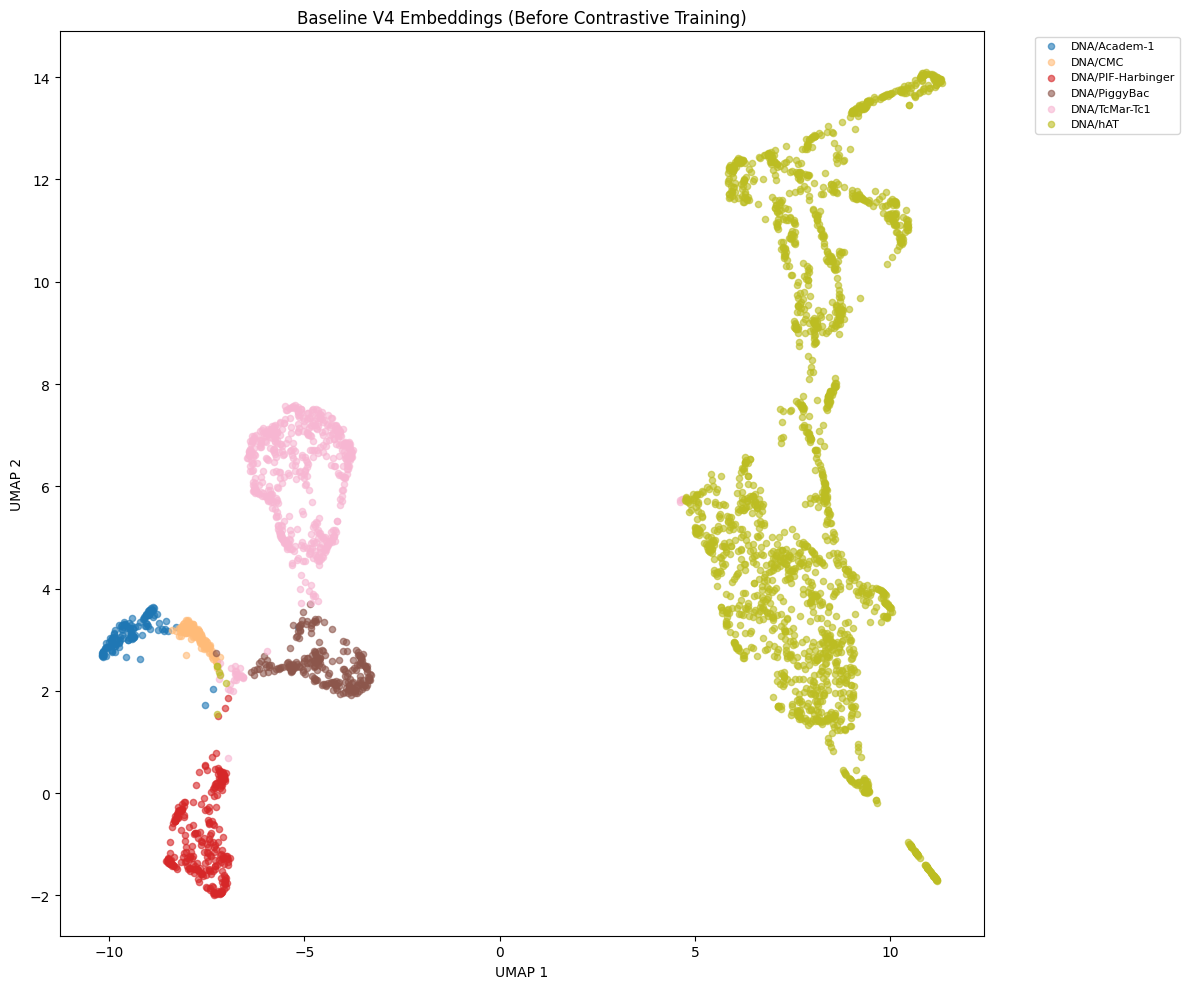

In [25]:
# Visualize baseline UMAP
print("\nBaseline UMAP visualization:")
_ = plot_umap(
    fused_baseline, 
    sf_ids_baseline, 
    label_names=sf_names,
    title="Baseline V4 Embeddings (Before Contrastive Training)",
    save_path="baseline_umap.png"
)

## Step 6: Train Contrastive Model

In [26]:
# Train the model using Supervised Contrastive Loss (SupCon)
model, history = train_supcon(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    encoder_lr_mult=ENCODER_LR_MULT,
    temperature=TEMPERATURE,
    device=DEVICE,
    patience=15,
    save_dir=".",
    track_diagnostics=True
)

Training with Supervised Contrastive Loss (SupCon)
  - NO RC augmentation (V4 already has RC-invariance)
  - Positive pairs: same superfamily samples
  Epochs: 50
  Encoder LR: 1.00e-05
  Projection LR: 1.00e-04
  Temperature: 0.1
  Track diagnostics: True



Epoch 1/50:   0%|          | 0/402 [00:00<?, ?it/s]

Epoch   1: loss=2.2555 | sil=0.6033 | intra=0.839 inter=0.129 margin=0.710
  → Saved checkpoint at epoch 1
  → New best silhouette: 0.6033


Epoch 2/50:   0%|          | 0/402 [00:00<?, ?it/s]

Epoch   2: loss=2.2479 | sil=0.6112 | intra=0.844 inter=0.127 margin=0.717
  → New best silhouette: 0.6112


...

Epoch  40: loss=2.2305 | sil=0.6480 | intra=0.872 inter=0.115 margin=0.757
  → Saved checkpoint at epoch 40


Epoch 41/50:   0%|          | 0/402 [00:00<?, ?it/s]

Epoch  41: loss=2.2304 | sil=0.6482 | intra=0.872 inter=0.114 margin=0.757


Epoch 42/50:   0%|          | 0/402 [00:00<?, ?it/s]

Epoch  42: loss=2.2300 | sil=0.6479 | intra=0.872 inter=0.113 margin=0.759

Early stopping at epoch 42 (val_loss plateau)

TRAINING SUMMARY (SupCon - No RC Augmentation)
Best val_loss: 2.2259
Best silhouette: 0.6486
Final silhouette: 0.6479
Final intra-class similarity: 0.8721
Final inter-class similarity: 0.1129
Final margin (intra - inter): 0.7592

With SupCon, silhouette should INCREASE (or at least not decrease).
If it still decreases, check batch size (need multiple same-SF samples per batch).


Found 7 checkpoints to compare
Epoch   1: val_loss=2.2555 | sil=0.5430 | ari=0.5764 | nmi=0.7824
Epoch  10: val_loss=2.2366 | sil=0.5651 | ari=0.5789 | nmi=0.7840
Epoch  15: val_loss=2.2285 | sil=0.5683 | ari=0.5782 | nmi=0.7837
Epoch  20: val_loss=2.2298 | sil=0.5712 | ari=0.5775 | nmi=0.7818
Epoch  30: val_loss=2.2305 | sil=0.5702 | ari=0.5770 | nmi=0.7815
Epoch  40: val_loss=2.2305 | sil=0.5694 | ari=0.5772 | nmi=0.7810
Epoch   5: val_loss=2.2324 | sil=0.5574 | ari=0.5770 | nmi=0.7821

BEST CHECKPOINTS BY DIFFERENT CRITERIA:
Best by val_loss: Epoch 15 (loss=2.2285, sil=0.5683)
Best by silhouette: Epoch 20 (loss=2.2298, sil=0.5712)
Best by ARI: Epoch 10 (loss=2.2366, ari=0.5789)

→ RECOMMENDED (balanced): Epoch 20 (loss=2.2298, sil=0.5712)


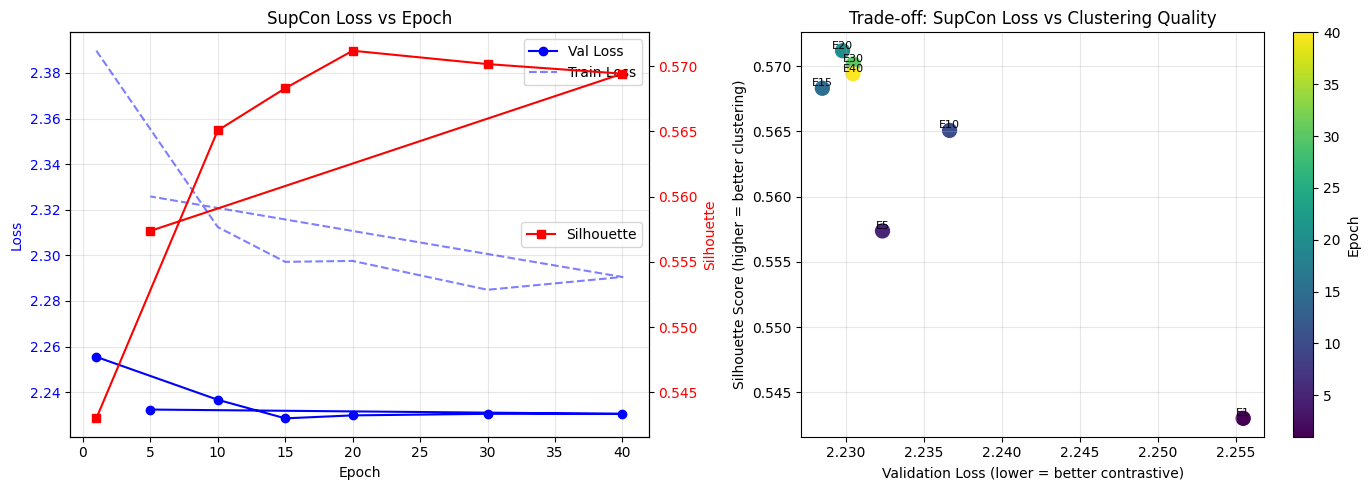

Saved: checkpoint_comparison.png


In [30]:
# ============ Compare Checkpoints Across Epochs ============

def compare_checkpoints(
    model_class,
    arch: Dict,
    val_loader: DataLoader,
    checkpoint_dir: str = ".",
    device: torch.device = None
) -> pd.DataFrame:
    """
    Load and compare checkpoints saved at different epochs.
    Helps find the best trade-off between contrastive loss and clustering.
    """
    if device is None:
        device = resolve_device()
    
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_files = sorted(checkpoint_dir.glob("supcon_epoch*.pt"))  # FIXED: supcon_ prefix
    
    if not checkpoint_files:
        print("No epoch checkpoints found. Skipping comparison.")
        return None
    
    print(f"Found {len(checkpoint_files)} checkpoints to compare")
    print("=" * 70)
    
    results = []
    
    for ckpt_path in checkpoint_files:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        epoch = ckpt.get('epoch', int(ckpt_path.stem.split('epoch')[-1]))
        
        # Load model - FIXED: Use correct arch keys from V4 checkpoint
        # FIXED: Set keep_binary_head=False since checkpoints don't have binary head
        model = ContrastiveTEEncoder(
            cnn_width=arch['cnn_width'],
            motif_kernels=arch['motif_kernels'],
            context_dilations=arch['context_dilations'],
            rc_mode=arch['rc_mode'],
            gnn_in_dim=arch['gnn_in_dim'],
            gnn_hidden=arch['gnn_hidden'],
            gnn_layers=arch['gnn_layers'],
            fusion_dim=arch['fusion_dim'],
            num_heads=arch['num_heads'],
            keep_binary_head=False,
            proj_dim=PROJ_DIM
        ).to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        
        # Extract embeddings
        all_embeds = []
        all_sf_ids = []
        
        with torch.no_grad():
            for batch in val_loader:
                # FIXED: Use new batch keys from collate_simple
                X = batch['X'].to(device)
                mask = batch['mask'].to(device)
                x_gnn = batch['x_gnn'].to(device)
                edge_index = batch['edge_index'].to(device)
                batch_vec = batch['batch_vec'].to(device)
                
                z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
                all_embeds.append(fused.cpu().numpy())
                all_sf_ids.append(batch['sf_ids'].numpy())
        
        embeddings = np.concatenate(all_embeds, axis=0)
        sf_ids = np.concatenate(all_sf_ids, axis=0)
        
        # Evaluate clustering
        n_clusters = len(np.unique(sf_ids))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        pred = kmeans.fit_predict(embeddings)
        
        sil = silhouette_score(embeddings, sf_ids)
        ari = adjusted_rand_score(sf_ids, pred)
        nmi = normalized_mutual_info_score(sf_ids, pred)
        
        results.append({
            'epoch': epoch,
            'val_loss': ckpt.get('val_loss', np.nan),
            'train_loss': ckpt.get('train_loss', np.nan),
            'silhouette': sil,
            'ari': ari,
            'nmi': nmi
        })
        
        print(f"Epoch {epoch:3d}: val_loss={ckpt.get('val_loss', np.nan):.4f} | "
              f"sil={sil:.4f} | ari={ari:.4f} | nmi={nmi:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find best by different criteria
    print("\n" + "=" * 70)
    print("BEST CHECKPOINTS BY DIFFERENT CRITERIA:")
    print("=" * 70)
    
    best_loss = results_df.loc[results_df['val_loss'].idxmin()]
    print(f"Best by val_loss: Epoch {int(best_loss['epoch'])} "
          f"(loss={best_loss['val_loss']:.4f}, sil={best_loss['silhouette']:.4f})")
    
    best_sil = results_df.loc[results_df['silhouette'].idxmax()]
    print(f"Best by silhouette: Epoch {int(best_sil['epoch'])} "
          f"(loss={best_sil['val_loss']:.4f}, sil={best_sil['silhouette']:.4f})")
    
    best_ari = results_df.loc[results_df['ari'].idxmax()]
    print(f"Best by ARI: Epoch {int(best_ari['epoch'])} "
          f"(loss={best_ari['val_loss']:.4f}, ari={best_ari['ari']:.4f})")
    
    # Suggest a balanced choice
    # Normalize metrics and find Pareto-optimal
    df_norm = results_df.copy()
    df_norm['loss_norm'] = (df_norm['val_loss'] - df_norm['val_loss'].min()) / (df_norm['val_loss'].max() - df_norm['val_loss'].min() + 1e-8)
    df_norm['sil_norm'] = (df_norm['silhouette'] - df_norm['silhouette'].min()) / (df_norm['silhouette'].max() - df_norm['silhouette'].min() + 1e-8)
    # Balance: low loss + high silhouette
    df_norm['combined'] = 0.5 * (1 - df_norm['loss_norm']) + 0.5 * df_norm['sil_norm']
    best_balanced = results_df.loc[df_norm['combined'].idxmax()]
    
    print(f"\n→ RECOMMENDED (balanced): Epoch {int(best_balanced['epoch'])} "
          f"(loss={best_balanced['val_loss']:.4f}, sil={best_balanced['silhouette']:.4f})")
    
    return results_df


# Compare checkpoints (if any exist)
checkpoint_comparison = compare_checkpoints(
    model_class=ContrastiveTEEncoder,
    arch=arch,
    val_loader=val_loader,
    checkpoint_dir=".",
    device=DEVICE
)

if checkpoint_comparison is not None:
    # Plot the trade-off
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.plot(checkpoint_comparison['epoch'], checkpoint_comparison['val_loss'], 'b-o', label='Val Loss')
    ax.plot(checkpoint_comparison['epoch'], checkpoint_comparison['train_loss'], 'b--', alpha=0.5, label='Train Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.legend(loc='upper right')
    ax.set_title('SupCon Loss vs Epoch')
    ax.grid(True, alpha=0.3)
    
    ax2 = ax.twinx()
    ax2.plot(checkpoint_comparison['epoch'], checkpoint_comparison['silhouette'], 'r-s', label='Silhouette')
    ax2.set_ylabel('Silhouette', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='center right')
    
    ax = axes[1]
    ax.scatter(checkpoint_comparison['val_loss'], checkpoint_comparison['silhouette'], 
               c=checkpoint_comparison['epoch'], cmap='viridis', s=100)
    for i, row in checkpoint_comparison.iterrows():
        ax.annotate(f"E{int(row['epoch'])}", (row['val_loss'], row['silhouette']), 
                   fontsize=8, ha='center', va='bottom')
    ax.set_xlabel('Validation Loss (lower = better contrastive)')
    ax.set_ylabel('Silhouette Score (higher = better clustering)')
    ax.set_title('Trade-off: SupCon Loss vs Clustering Quality')
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', 
                 norm=plt.Normalize(checkpoint_comparison['epoch'].min(), 
                                   checkpoint_comparison['epoch'].max())), 
                 ax=ax, label='Epoch')
    
    plt.tight_layout()
    plt.savefig("checkpoint_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: checkpoint_comparison.png")

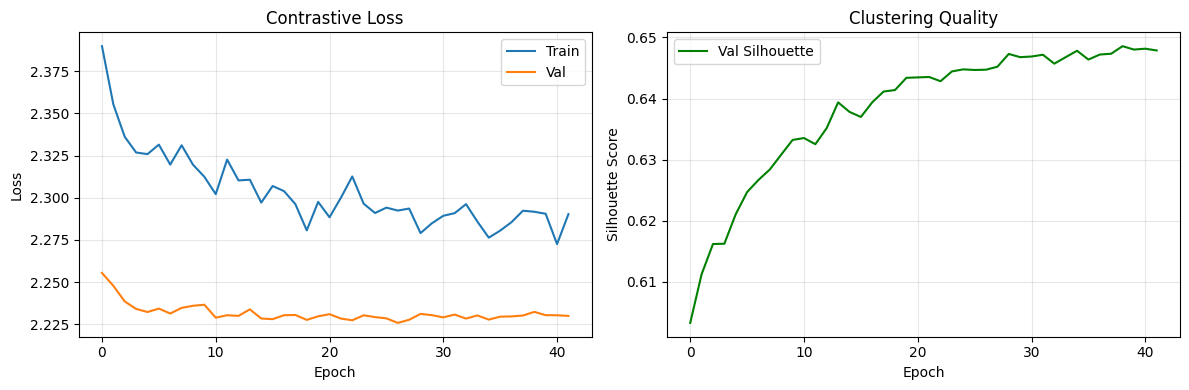

In [31]:
# Plot training history
plot_training_history(history, save_path="contrastive_training_history.png")

## Step 7: Evaluate After Contrastive Training

In [32]:
# Extract embeddings after contrastive training
print("Extracting post-training embeddings...")
z_post, fused_post, sf_ids_post, headers_post = extract_embeddings(
    model, val_loader, DEVICE
)

# Evaluate clustering
print("\n=== Post-Training Clustering (K-Means) ===")
post_kmeans = evaluate_clustering(fused_post, sf_ids_post, method='kmeans')
print(f"  Silhouette: {post_kmeans['silhouette']:.4f} (baseline: {baseline_kmeans['silhouette']:.4f})")
print(f"  ARI: {post_kmeans['ari']:.4f} (baseline: {baseline_kmeans['ari']:.4f})")
print(f"  NMI: {post_kmeans['nmi']:.4f} (baseline: {baseline_kmeans['nmi']:.4f})")

print("\n=== Post-Training Clustering (HDBSCAN) ===")
post_hdbscan = evaluate_clustering(fused_post, sf_ids_post, method='hdbscan')
print(f"  Clusters found: {post_hdbscan['n_clusters']}")
print(f"  Silhouette: {post_hdbscan.get('silhouette', -1):.4f}")
print(f"  ARI: {post_hdbscan.get('ari', -1):.4f}")
print(f"  NMI: {post_hdbscan.get('nmi', -1):.4f}")

Extracting post-training embeddings...


Extracting embeddings:   0%|          | 0/101 [00:00<?, ?it/s]


=== Post-Training Clustering (K-Means) ===
  Silhouette: 0.5876 (baseline: 0.5516)
  ARI: 0.5772 (baseline: 0.5758)
  NMI: 0.7815 (baseline: 0.7821)

=== Post-Training Clustering (HDBSCAN) ===
  HDBSCAN: 866 noise points
  Clusters found: 13
  Silhouette: 0.6269
  ARI: 0.6923
  NMI: 0.8212



Post-training UMAP visualization:
Computing UMAP projection...


/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved to contrastive_umap.png


/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_96991/1531513369.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')


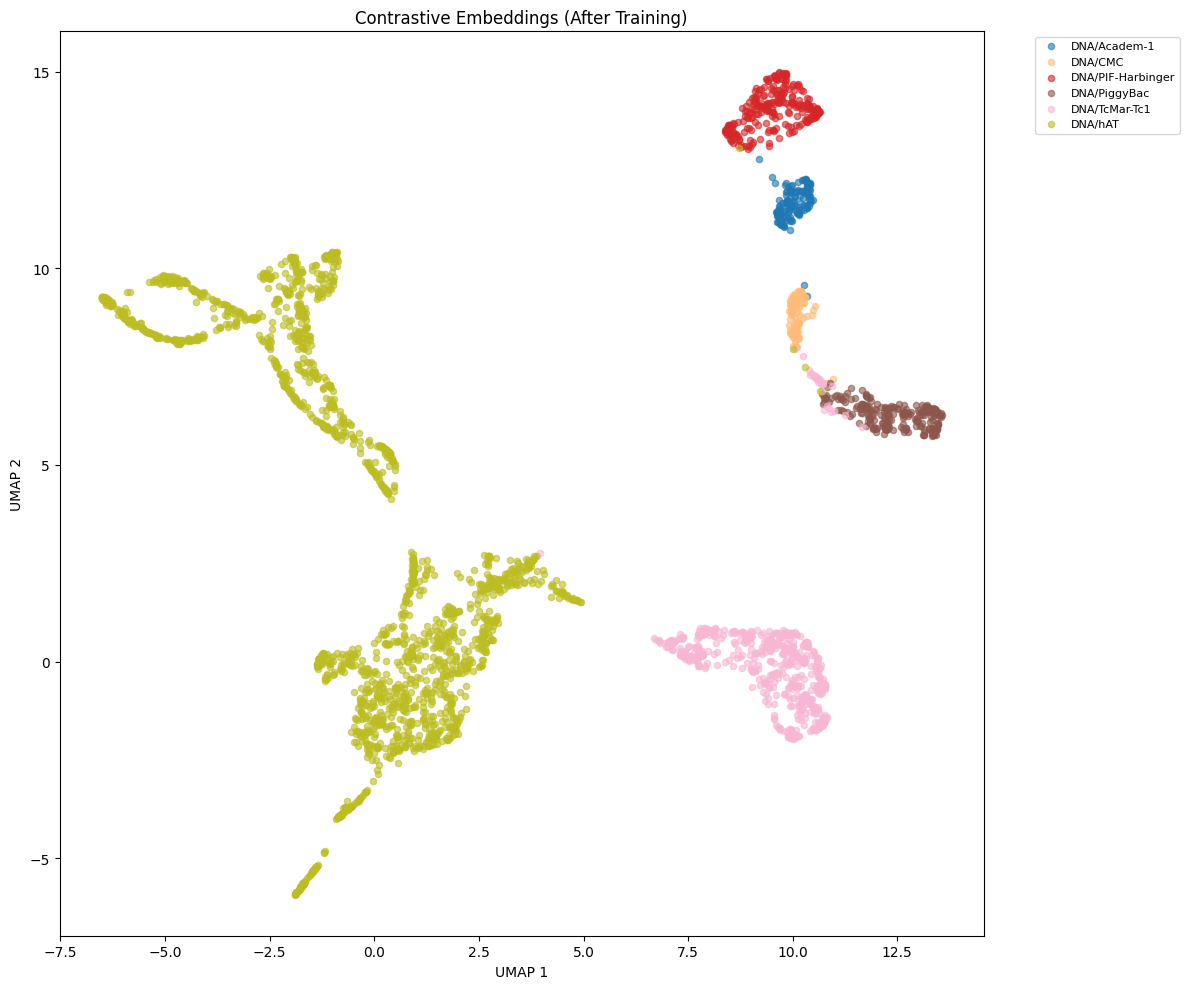

In [33]:
# Visualize post-training UMAP
print("\nPost-training UMAP visualization:")
_ = plot_umap(
    fused_post, 
    sf_ids_post, 
    label_names=sf_names,
    title="Contrastive Embeddings (After Training)",
    save_path="contrastive_umap.png"
)

## Step 8: Compare Baseline vs Contrastive Embeddings

In [34]:
# Summary comparison
print("=" * 60)
print("SUMMARY: Baseline vs Contrastive Training")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric': ['Silhouette', 'ARI', 'NMI'],
    'Baseline (K-Means)': [
        baseline_kmeans['silhouette'],
        baseline_kmeans['ari'],
        baseline_kmeans['nmi']
    ],
    'Contrastive (K-Means)': [
        post_kmeans['silhouette'],
        post_kmeans['ari'],
        post_kmeans['nmi']
    ],
    'Improvement': [
        post_kmeans['silhouette'] - baseline_kmeans['silhouette'],
        post_kmeans['ari'] - baseline_kmeans['ari'],
        post_kmeans['nmi'] - baseline_kmeans['nmi']
    ]
})

print(comparison.to_string(index=False))

# Highlight improvements
print("\n" + "=" * 60)
for _, row in comparison.iterrows():
    metric = row['Metric']
    imp = row['Improvement']
    if imp > 0:
        print(f"✅ {metric}: +{imp:.4f} improvement")
    else:
        print(f"❌ {metric}: {imp:.4f} (decreased)")

SUMMARY: Baseline vs Contrastive Training
    Metric  Baseline (K-Means)  Contrastive (K-Means)  Improvement
Silhouette            0.551617               0.587610     0.035993
       ARI            0.575824               0.577235     0.001411
       NMI            0.782118               0.781486    -0.000631

✅ Silhouette: +0.0360 improvement
✅ ARI: +0.0014 improvement
❌ NMI: -0.0006 (decreased)


## Step 9: Save Final Model and Embeddings

In [35]:
# Save the final model
final_save_path = Path(".") / "contrastive_final.pt"
torch.save({
    'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
    'history': history,
    'arch': arch,
    'sf_names': sf_names,
    'sf_to_id': sf_to_id,
    'config': {
        'proj_dim': PROJ_DIM,
        'temperature': TEMPERATURE,
        'lr': LR,
        'encoder_lr_mult': ENCODER_LR_MULT
    }
}, final_save_path)
print(f"Saved final model to {final_save_path}")

# Save embeddings for further analysis
embeddings_df = pd.DataFrame({
    'header': headers_post,
    'superfamily': [sf_names[i] for i in sf_ids_post],
    'sf_id': sf_ids_post,
    **{f'embed_{i}': fused_post[:, i] for i in range(fused_post.shape[1])}
})
embeddings_df.to_csv("contrastive_embeddings.csv", index=False)
print(f"Saved embeddings to contrastive_embeddings.csv ({len(embeddings_df)} rows)")

Saved final model to contrastive_final.pt
Saved embeddings to contrastive_embeddings.csv (3213 rows)


---

## Next Steps

Based on the results, consider the following improvements:

### 1. **Additional Augmentation Strategies**
- **Overlapping windows**: Sample two random overlapping crops from the same TE
- **Masked motifs**: Randomly mask TIRs or transposase domains
- **Random deletion/insertion**: Small sequence perturbations

### 2. **Multi-Positive Contrastive Learning**
- Instead of just RC pairs, treat all sequences from the same superfamily as soft positives
- Use Supervised Contrastive Loss (SupCon) with superfamily as weak labels

### 3. **Hierarchical Clustering Analysis**
- Apply HDBSCAN to find natural clusters
- Compare discovered clusters to known superfamilies
- Identify potential novel subfamilies

### 4. **Transfer to New Datasets**
- Use the trained encoder to embed sequences from other TE databases
- Evaluate cross-dataset clustering performance

### 5. **Fine-grained Subfamily Discovery**
- Within each superfamily, apply clustering to discover subfamilies
- Use the embedding space for phylogenetic analysis

---

# Fine-Grained Subfamily Discovery

The UMAP visualization shows that some superfamilies naturally split into distinct subclusters. This section implements automatic subcluster discovery using HDBSCAN, followed by supervised contrastive learning to reinforce the fine-grained structure.

**Approach:**
1. **Discover subclusters**: Run HDBSCAN within each superfamily to find natural subclusters
2. **Create fine-grained labels**: Assign each sequence to a superfamily+subcluster
3. **Supervised Contrastive Loss (SupCon)**: Train with subclusters as positive pairs

## Step 10: Subcluster Discovery with HDBSCAN

In [36]:
# ============ Subcluster Discovery ============

from sklearn.cluster import HDBSCAN
from collections import defaultdict

def discover_subclusters(
    embeddings: np.ndarray,
    superfamily_ids: np.ndarray,
    sf_names: List[str],
    min_cluster_size: int = 10,
    min_samples: int = 5,
    metric: str = 'euclidean'
) -> Tuple[np.ndarray, Dict[str, List[int]], Dict[int, str]]:
    """
    Discover subclusters within each superfamily using HDBSCAN.
    
    Args:
        embeddings: (N, D) embedding vectors
        superfamily_ids: (N,) superfamily ID for each sample
        sf_names: List of superfamily names
        min_cluster_size: HDBSCAN minimum cluster size
        min_samples: HDBSCAN min_samples parameter
        metric: Distance metric
        
    Returns:
        subcluster_ids: (N,) unique subcluster ID for each sample
        sf_subclusters: Dict mapping superfamily -> list of subcluster IDs
        subcluster_names: Dict mapping subcluster_id -> "superfamily::subN" name
    """
    unique_sfs = np.unique(superfamily_ids)
    
    # Subcluster ID assignment (global across all superfamilies)
    subcluster_ids = np.zeros(len(embeddings), dtype=np.int64)
    sf_subclusters = defaultdict(list)
    subcluster_names = {}
    
    next_subcluster_id = 0
    
    print(f"Discovering subclusters (min_cluster_size={min_cluster_size}, min_samples={min_samples})")
    print("-" * 60)
    
    for sf_id in tqdm(unique_sfs, desc="Processing superfamilies"):
        sf_name = sf_names[sf_id]
        mask = superfamily_ids == sf_id
        sf_embeds = embeddings[mask]
        sf_indices = np.where(mask)[0]
        n_samples = len(sf_embeds)
        
        if n_samples < min_cluster_size:
            # Too small to cluster - treat as single subcluster
            subcluster_ids[sf_indices] = next_subcluster_id
            sf_subclusters[sf_name].append(next_subcluster_id)
            subcluster_names[next_subcluster_id] = f"{sf_name}::sub0"
            next_subcluster_id += 1
            continue
        
        # Run HDBSCAN within this superfamily
        clusterer = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric=metric,
            cluster_selection_method='eom'  # Excess of Mass
        )
        
        local_labels = clusterer.fit_predict(sf_embeds)
        
        # Handle noise points (-1) by assigning to nearest cluster
        noise_mask = local_labels == -1
        n_noise = noise_mask.sum()
        
        if n_noise > 0 and n_noise < len(local_labels):
            # Assign noise points to nearest non-noise cluster
            from sklearn.neighbors import NearestNeighbors
            
            non_noise_embeds = sf_embeds[~noise_mask]
            non_noise_labels = local_labels[~noise_mask]
            
            if len(non_noise_embeds) > 0:
                nn = NearestNeighbors(n_neighbors=1, metric=metric)
                nn.fit(non_noise_embeds)
                _, indices = nn.kneighbors(sf_embeds[noise_mask])
                local_labels[noise_mask] = non_noise_labels[indices.flatten()]
        elif n_noise == len(local_labels):
            # All points are noise - treat as single cluster
            local_labels[:] = 0
        
        # Map local cluster IDs to global subcluster IDs
        unique_local = np.unique(local_labels)
        for local_id in sorted(unique_local):
            local_mask = local_labels == local_id
            global_indices = sf_indices[local_mask]
            
            subcluster_ids[global_indices] = next_subcluster_id
            sf_subclusters[sf_name].append(next_subcluster_id)
            subcluster_names[next_subcluster_id] = f"{sf_name}::sub{len(sf_subclusters[sf_name])-1}"
            next_subcluster_id += 1
    
    # Print summary
    print("-" * 60)
    print(f"Total subclusters discovered: {next_subcluster_id}")
    
    # Find superfamilies with multiple subclusters
    multi_sub_sfs = [(sf, subs) for sf, subs in sf_subclusters.items() if len(subs) > 1]
    multi_sub_sfs.sort(key=lambda x: -len(x[1]))
    
    print(f"\nSuperfamilies with multiple subclusters ({len(multi_sub_sfs)}):")
    for sf, subs in multi_sub_sfs[:15]:
        n_per_sub = [(subcluster_ids == sub_id).sum() for sub_id in subs]
        print(f"  {sf}: {len(subs)} subclusters ({n_per_sub})")
    
    if len(multi_sub_sfs) > 15:
        print(f"  ... and {len(multi_sub_sfs) - 15} more")
    
    return subcluster_ids, dict(sf_subclusters), subcluster_names

In [37]:
# Run subcluster discovery on contrastive embeddings
# First, get all embeddings (need to re-extract if model was trained)

@torch.no_grad()
def extract_all_embeddings_with_subclusters(
    model: nn.Module,
    headers: List[str],
    sequences: List[str],
    superfamilies: List[str],
    kmer_features: List[np.ndarray],
    sf_to_id: Dict[str, int],
    batch_size: int = 64,
    device: torch.device = torch.device('cpu')
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Extract embeddings for all sequences."""
    model.eval()
    
    # FIXED: Use SimpleContrastiveDataset (no RC augmentation)
    temp_ds = SimpleContrastiveDataset(
        headers=headers,
        sequences=sequences,
        superfamilies=superfamilies,
        kmer_features=kmer_features,
        fixed_length=FIXED_LENGTH
    )
    
    # FIXED: Use collate_simple
    temp_loader = DataLoader(
        temp_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=partial(collate_simple, fixed_length=FIXED_LENGTH),
        num_workers=0
    )
    
    all_embeds = []
    all_sf_ids = []
    all_headers = []
    
    for batch in tqdm(temp_loader, desc="Extracting embeddings"):
        # FIXED: Use new batch keys from collate_simple
        X = batch['X'].to(device)
        mask = batch['mask'].to(device)
        x_gnn = batch['x_gnn'].to(device)
        edge_index = batch['edge_index'].to(device)
        batch_vec = batch['batch_vec'].to(device)
        
        # model returns (z, fused, binary_logits, gate_weights)
        z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
        
        all_embeds.append(z.cpu().numpy())
        all_sf_ids.append(batch['sf_ids'].numpy())
        all_headers.extend(batch['headers'])
    
    embeddings = np.concatenate(all_embeds, axis=0)
    sf_ids = np.concatenate(all_sf_ids, axis=0)
    
    return embeddings, sf_ids, all_headers


# Extract embeddings for all sequences
print("Extracting embeddings for subcluster discovery...")
all_embeddings, all_sf_ids, all_headers_ordered = extract_all_embeddings_with_subclusters(
    model=model,
    headers=headers,
    sequences=sequences,
    superfamilies=superfamilies,
    kmer_features=kmer_features,
    sf_to_id=sf_to_id,
    batch_size=BATCH_SIZE,
    device=DEVICE
)

print(f"Extracted embeddings: {all_embeddings.shape}")

Extracting embeddings for subcluster discovery...
SimpleContrastiveDataset: 16065 sequences, 6 superfamilies


Extracting embeddings:   0%|          | 0/503 [00:00<?, ?it/s]

Extracted embeddings: (16065, 128)


In [38]:
# Discover subclusters within each superfamily
subcluster_ids, sf_subclusters, subcluster_names = discover_subclusters(
    embeddings=all_embeddings,
    superfamily_ids=all_sf_ids,
    sf_names=sf_names,
    min_cluster_size=15,   # Minimum subcluster size
    min_samples=5,         # HDBSCAN density parameter
    metric='euclidean'
)

print(f"\nTotal unique subclusters: {len(subcluster_names)}")
print(f"Average subclusters per superfamily: {len(subcluster_names) / len(sf_names):.2f}")

Discovering subclusters (min_cluster_size=15, min_samples=5)
------------------------------------------------------------


Processing superfamilies:   0%|          | 0/6 [00:00<?, ?it/s]

------------------------------------------------------------
Total subclusters discovered: 12

Superfamilies with multiple subclusters (5):
  DNA/Academ-1: 3 subclusters ([77, 139, 523])
  DNA/PIF-Harbinger: 2 subclusters ([1179, 185])
  DNA/PiggyBac: 2 subclusters ([780, 404])
  DNA/TcMar-Tc1: 2 subclusters ([2698, 109])
  DNA/hAT: 2 subclusters ([9360, 49])

Total unique subclusters: 12
Average subclusters per superfamily: 2.00


## Step 11: Visualize Subclusters

Computing UMAP projection...


/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_96991/2184587553.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_sfs))
/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_96991/2184587553.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sub = plt.cm.get_cmap('gist_ncar', n_subclusters)


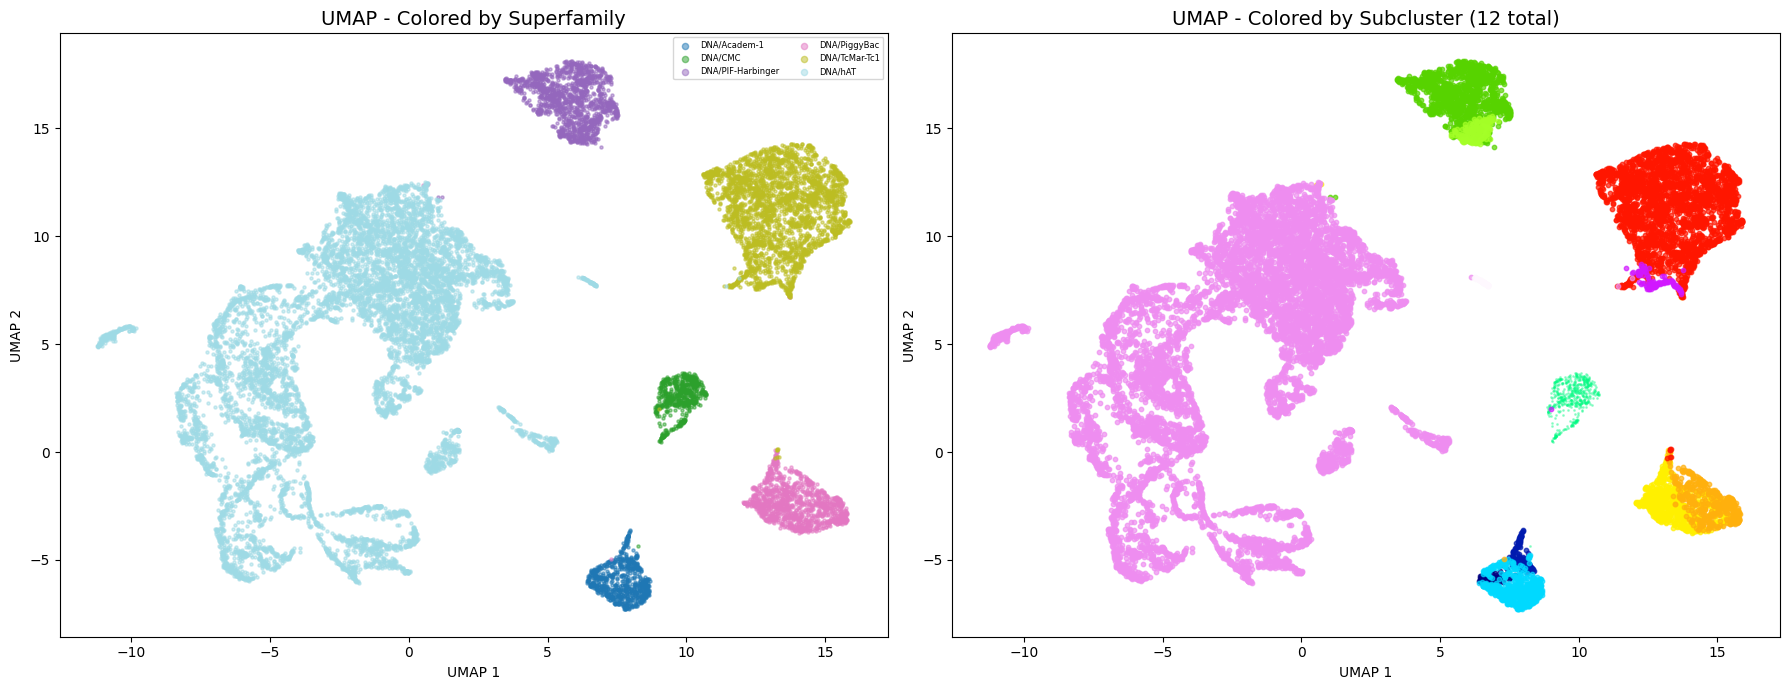

Saved: subcluster_umap.png


In [41]:
# Visualize subclusters with UMAP
import umap

def plot_subclusters_umap(
    embeddings: np.ndarray,
    sf_ids: np.ndarray,
    subcluster_ids: np.ndarray,
    sf_names: List[str],
    subcluster_names: Dict[int, str],
    figsize: Tuple[int, int] = (18, 7),
    n_neighbors: int = 30,
    min_dist: float = 0.3
):
    """Create side-by-side UMAP: superfamily colors vs subcluster colors."""
    
    print("Computing UMAP projection...")
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
    umap_coords = reducer.fit_transform(embeddings)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Left: Color by superfamily
    ax = axes[0]
    unique_sfs = np.unique(sf_ids)
    cmap = plt.cm.get_cmap('tab20', len(unique_sfs))
    
    for i, sf_id in enumerate(unique_sfs):
        mask = sf_ids == sf_id
        ax.scatter(
            umap_coords[mask, 0], 
            umap_coords[mask, 1],
            c=[cmap(i)], 
            s=5, 
            alpha=0.5,
            label=sf_names[sf_id] if mask.sum() > 50 else None
        )
    
    ax.set_title("UMAP - Colored by Superfamily", fontsize=14)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(loc='upper right', fontsize=6, ncol=2, markerscale=2)
    
    # Right: Color by subcluster
    ax = axes[1]
    unique_subclusters = np.unique(subcluster_ids)
    n_subclusters = len(unique_subclusters)
    cmap_sub = plt.cm.get_cmap('gist_ncar', n_subclusters)
    
    # Find superfamilies with multiple subclusters for highlighting
    multi_sub_sfs = set(sf for sf, subs in sf_subclusters.items() if len(subs) > 1)
    
    for sub_id in unique_subclusters:
        mask = subcluster_ids == sub_id
        sub_name = subcluster_names[sub_id]
        sf_name = sub_name.split("::")[0]
        
        # Use different marker for multi-subcluster superfamilies
        marker = 'o' if sf_name in multi_sub_sfs else '.'
        alpha = 0.7 if sf_name in multi_sub_sfs else 0.3
        s = 10 if sf_name in multi_sub_sfs else 5
        
        ax.scatter(
            umap_coords[mask, 0], 
            umap_coords[mask, 1],
            c=[cmap_sub(sub_id % n_subclusters)], 
            s=s, 
            alpha=alpha,
            marker=marker
        )
    
    ax.set_title(f"UMAP - Colored by Subcluster ({n_subclusters} total)", fontsize=14)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    
    plt.tight_layout()
    plt.savefig("subcluster_umap.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: subcluster_umap.png")
    
    return umap_coords


# Plot subclusters
umap_coords_sub = plot_subclusters_umap(
    embeddings=all_embeddings,
    sf_ids=all_sf_ids,
    subcluster_ids=subcluster_ids,
    sf_names=sf_names,
    subcluster_names=subcluster_names
)

## Step 12: Supervised Contrastive Learning with Subclusters

Now we'll use **Supervised Contrastive Loss (SupCon)** to reinforce the discovered subcluster structure. This loss:
- Pulls together samples from the **same subcluster**
- Pushes apart samples from **different subclusters**

$$\mathcal{L}_{sup} = \sum_{i} \frac{-1}{|P(i)|} \sum_{p \in P(i)} \log \frac{\exp(z_i \cdot z_p / \tau)}{\sum_{a \neq i} \exp(z_i \cdot z_a / \tau)}$$

Where $P(i)$ is the set of samples in the batch with the same subcluster label as sample $i$.

In [42]:
# ============ Supervised Contrastive Loss (SupCon) ============

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss from "Supervised Contrastive Learning" (Khosla et al., 2020)
    
    Uses label information to define positive pairs:
    - All samples with the same label are positives
    - All samples with different labels are negatives
    """
    def __init__(self, temperature: float = 0.1):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Compute SupCon loss.
        
        Args:
            features: (N, D) L2-normalized embeddings
            labels: (N,) integer labels
            
        Returns:
            Scalar loss
        """
        device = features.device
        N = features.size(0)
        
        # Compute similarity matrix
        sim = torch.mm(features, features.t()) / self.temperature
        
        # Mask out self-similarities
        self_mask = torch.eye(N, device=device, dtype=torch.bool)
        sim.masked_fill_(self_mask, -float('inf'))
        
        # Create positive mask: samples with same label
        labels = labels.view(-1, 1)
        pos_mask = (labels == labels.t()) & ~self_mask
        
        # If no positives in batch, return 0
        if pos_mask.sum() == 0:
            return torch.tensor(0.0, device=device)
        
        # Compute log_softmax over all other samples
        log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
        
        # Mean of positive log probabilities per sample
        # Only include samples that have positives
        pos_count = pos_mask.sum(dim=1).float()
        has_positives = pos_count > 0
        
        if has_positives.sum() == 0:
            return torch.tensor(0.0, device=device)
        
        # Compute mean positive log prob for each sample
        pos_log_prob = (log_prob * pos_mask.float()).sum(dim=1)
        pos_log_prob = pos_log_prob[has_positives] / pos_count[has_positives]
        
        # Loss is negative mean
        loss = -pos_log_prob.mean()
        
        return loss


class CombinedContrastiveLoss(nn.Module):
    """
    Combined loss: NT-Xent (RC pairs) + SupCon (subcluster labels).
    """
    def __init__(
        self, 
        temperature: float = 0.1,
        supcon_weight: float = 0.5
    ):
        super().__init__()
        self.ntxent = NTXentLoss(temperature)
        self.supcon = SupConLoss(temperature)
        self.supcon_weight = supcon_weight
    
    def forward(
        self, 
        z_orig: torch.Tensor, 
        z_aug: torch.Tensor,
        subcluster_labels: torch.Tensor
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Compute combined loss.
        
        Args:
            z_orig: (N, D) original embeddings
            z_aug: (N, D) augmented (RC) embeddings
            subcluster_labels: (N,) subcluster IDs
            
        Returns:
            total_loss: Combined loss
            loss_dict: Individual components
        """
        # NT-Xent for RC pairs
        ntxent_loss = self.ntxent(z_orig, z_aug)
        
        # SupCon on concatenated embeddings with shared labels
        z_combined = torch.cat([z_orig, z_aug], dim=0)
        labels_combined = torch.cat([subcluster_labels, subcluster_labels], dim=0)
        supcon_loss = self.supcon(z_combined, labels_combined)
        
        # Combine
        total = ntxent_loss + self.supcon_weight * supcon_loss
        
        return total, {
            'ntxent': ntxent_loss.item(),
            'supcon': supcon_loss.item(),
            'total': total.item()
        }

In [43]:
# ============ Dataset with Subcluster Labels ============

class SubclusterContrastiveDataset(Dataset):
    """
    Dataset for contrastive learning with subcluster labels.
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        superfamilies: List[str],
        subcluster_ids: np.ndarray,
        kmer_features: List[np.ndarray],
        fixed_length: int = 5000
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.superfamilies = list(superfamilies)
        self.subcluster_ids = np.asarray(subcluster_ids, dtype=np.int64)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        
        # Build superfamily mapping for evaluation
        sf_names = sorted(set(superfamilies))
        self.sf_to_id = {sf: i for i, sf in enumerate(sf_names)}
        self.sf_ids = np.array([self.sf_to_id[sf] for sf in superfamilies], dtype=np.int64)
    
    def __len__(self):
        return len(self.sequences)
    
    def _encode_sequence(self, seq: str) -> np.ndarray:
        seq_bytes = seq.encode("ascii", "ignore")
        return ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)
        
        # Original sequence
        seq_idx_orig = self._encode_sequence(seq)
        
        # Augmented: reverse complement
        seq_rc = reverse_complement_sequence(seq)
        seq_idx_rc = self._encode_sequence(seq_rc)
        
        # Random placement
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        
        # K-mer features
        kmer_orig = self.kmer_features[idx]
        kmer_rc = kmer_orig[::-1].copy()
        if kmer_rc.shape[1] > 0:
            kmer_rc[:, -1] = 1.0 - kmer_rc[:, -1]
        
        return (
            self.headers[idx],
            seq_idx_orig,
            seq_idx_rc,
            start_pos,
            seq_len,
            kmer_orig,
            kmer_rc,
            int(self.sf_ids[idx]),
            int(self.subcluster_ids[idx])  # Added subcluster ID
        )


def collate_subcluster_contrastive(batch, fixed_length=5000):
    """Collate function with subcluster labels."""
    (headers, seq_idxs_orig, seq_idxs_rc, starts, lengths, 
     kmer_orig, kmer_rc, sf_ids, subcluster_ids) = zip(*batch)
    
    B = len(batch)
    
    # CNN inputs (original)
    X_orig = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask_orig = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    # CNN inputs (RC)
    X_rc = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask_rc = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    for i, (seq_orig, seq_rc, start, seq_len) in enumerate(zip(seq_idxs_orig, seq_idxs_rc, starts, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx_orig = torch.from_numpy(seq_orig[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X_orig[i, idx_orig, pos] = 1.0
            mask_orig[i, start:start + actual_len] = (idx_orig != 4)
            
            idx_rc = torch.from_numpy(seq_rc[:actual_len].astype(np.int64))
            X_rc[i, idx_rc, pos] = 1.0
            mask_rc[i, start:start + actual_len] = (idx_rc != 4)
    
    # GNN inputs (original)
    xs_orig, eis_orig, batch_vecs_orig = [], [], []
    node_offset = 0
    for gi, kf in enumerate(kmer_orig):
        x = torch.from_numpy(kf).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        xs_orig.append(x)
        eis_orig.append(ei + node_offset)
        batch_vecs_orig.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n
    
    x_gnn_orig = torch.cat(xs_orig, dim=0)
    edge_index_orig = torch.cat(eis_orig, dim=1) if eis_orig else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec_orig = torch.cat(batch_vecs_orig, dim=0)
    
    # GNN inputs (RC)
    xs_rc, eis_rc, batch_vecs_rc = [], [], []
    node_offset = 0
    for gi, kf in enumerate(kmer_rc):
        x = torch.from_numpy(kf).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        xs_rc.append(x)
        eis_rc.append(ei + node_offset)
        batch_vecs_rc.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n
    
    x_gnn_rc = torch.cat(xs_rc, dim=0)
    edge_index_rc = torch.cat(eis_rc, dim=1) if eis_rc else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec_rc = torch.cat(batch_vecs_rc, dim=0)
    
    sf_ids = torch.tensor(sf_ids, dtype=torch.long)
    subcluster_ids = torch.tensor(subcluster_ids, dtype=torch.long)
    
    return {
        'headers': list(headers),
        'X_orig': X_orig, 'mask_orig': mask_orig,
        'x_gnn_orig': x_gnn_orig, 'edge_index_orig': edge_index_orig, 'batch_vec_orig': batch_vec_orig,
        'X_rc': X_rc, 'mask_rc': mask_rc,
        'x_gnn_rc': x_gnn_rc, 'edge_index_rc': edge_index_rc, 'batch_vec_rc': batch_vec_rc,
        'sf_ids': sf_ids,
        'subcluster_ids': subcluster_ids
    }

In [44]:
# ============ Training Loop with SupCon ============

def train_supcon(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 30,
    lr: float = 1e-4,
    encoder_lr_mult: float = 0.1,
    temperature: float = 0.1,
    supcon_weight: float = 0.5,
    device: torch.device = torch.device('cpu'),
    save_dir: Path = Path(".")
) -> Dict[str, List[float]]:
    """
    Train with combined NT-Xent + SupCon loss.
    """
    model = model.to(device)
    
    # Differential LR
    encoder_params = []
    proj_params = []
    for name, param in model.named_parameters():
        if 'proj_head' in name:
            proj_params.append(param)
        else:
            encoder_params.append(param)
    
    optimizer = torch.optim.AdamW([
        {'params': encoder_params, 'lr': lr * encoder_lr_mult},
        {'params': proj_params, 'lr': lr}
    ], weight_decay=0.01)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = CombinedContrastiveLoss(temperature=temperature, supcon_weight=supcon_weight)
    
    history = {'train_loss': [], 'val_loss': [], 'ntxent': [], 'supcon': []}
    best_val_loss = float('inf')
    bad_epochs = 0
    patience = 15  # Early stopping patience
    checkpoint_epochs = [1, 5, 10, 15, 20, 25, 30]
    
    print(f"Training with SupCon for {epochs} epochs")
    print(f"  Encoder LR: {lr * encoder_lr_mult:.2e}, Proj LR: {lr:.2e}")
    print(f"  SupCon weight: {supcon_weight}")
    print()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        train_ntxent = []
        train_supcon = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in pbar:
            # Original view
            X_orig = batch['X_orig'].to(device)
            mask_orig = batch['mask_orig'].to(device)
            x_gnn_orig = batch['x_gnn_orig'].to(device)
            edge_index_orig = batch['edge_index_orig'].to(device)
            batch_vec_orig = batch['batch_vec_orig'].to(device)
            
            # RC view
            X_rc = batch['X_rc'].to(device)
            mask_rc = batch['mask_rc'].to(device)
            x_gnn_rc = batch['x_gnn_rc'].to(device)
            edge_index_rc = batch['edge_index_rc'].to(device)
            batch_vec_rc = batch['batch_vec_rc'].to(device)
            
            # Subcluster labels
            subcluster_labels = batch['subcluster_ids'].to(device)
            
            # Forward - FIXED: model returns (z, fused, binary_logits, gate_weights)
            z_orig, _, _, _ = model(X_orig, mask_orig, x_gnn_orig, edge_index_orig, batch_vec_orig)
            z_rc, _, _, _ = model(X_rc, mask_rc, x_gnn_rc, edge_index_rc, batch_vec_rc)
            
            # Combined loss
            loss, loss_dict = loss_fn(z_orig, z_rc, subcluster_labels)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_losses.append(loss_dict['total'])
            train_ntxent.append(loss_dict['ntxent'])
            train_supcon.append(loss_dict['supcon'])
            pbar.set_postfix(loss=f"{loss_dict['total']:.4f}")
        
        # Validation
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for batch in val_loader:
                X_orig = batch['X_orig'].to(device)
                mask_orig = batch['mask_orig'].to(device)
                x_gnn_orig = batch['x_gnn_orig'].to(device)
                edge_index_orig = batch['edge_index_orig'].to(device)
                batch_vec_orig = batch['batch_vec_orig'].to(device)
                
                X_rc = batch['X_rc'].to(device)
                mask_rc = batch['mask_rc'].to(device)
                x_gnn_rc = batch['x_gnn_rc'].to(device)
                edge_index_rc = batch['edge_index_rc'].to(device)
                batch_vec_rc = batch['batch_vec_rc'].to(device)
                
                subcluster_labels = batch['subcluster_ids'].to(device)
                
                # Forward - FIXED: model returns (z, fused, binary_logits, gate_weights)
                z_orig, _, _, _ = model(X_orig, mask_orig, x_gnn_orig, edge_index_orig, batch_vec_orig)
                z_rc, _, _, _ = model(X_rc, mask_rc, x_gnn_rc, edge_index_rc, batch_vec_rc)
                
                loss, loss_dict = loss_fn(z_orig, z_rc, subcluster_labels)
                val_losses.append(loss_dict['total'])
        
        scheduler.step()
        
        # Log
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        mean_ntxent = np.mean(train_ntxent)
        mean_supcon = np.mean(train_supcon)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['ntxent'].append(mean_ntxent)
        history['supcon'].append(mean_supcon)
        
        print(f"Epoch {epoch+1}: train={train_loss:.4f} val={val_loss:.4f} "
              f"(ntxent={mean_ntxent:.4f}, supcon={mean_supcon:.4f})")
        
        # Save periodic checkpoints
        if (epoch + 1) in checkpoint_epochs:
            ckpt_path = save_dir / f"supcon_epoch{epoch+1}.pt"
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'history': {k: v[:] for k, v in history.items()}
            }, ckpt_path)
            print(f"  → Saved checkpoint at epoch {epoch+1}")
        
        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            bad_epochs = 0
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'history': history
            }, save_dir / "supcon_best.pt")
            print(f"  → Saved best model (val_loss={val_loss:.4f})")
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"\nEarly stopping at epoch {epoch+1} (val_loss plateau)")
                break
    
    return history

## Step 13: Train with Subcluster-Aware SupCon Loss

In [45]:
# Create a mapping from original headers to subcluster IDs
header_to_subcluster = dict(zip(all_headers_ordered, subcluster_ids))

# Create new datasets with subcluster labels
train_subcluster_ids = np.array([header_to_subcluster[headers[i]] for i in train_idx])
val_subcluster_ids = np.array([header_to_subcluster[headers[i]] for i in val_idx])

train_ds_supcon = SubclusterContrastiveDataset(
    headers=[headers[i] for i in train_idx],
    sequences=[sequences[i] for i in train_idx],
    superfamilies=[superfamilies[i] for i in train_idx],
    subcluster_ids=train_subcluster_ids,
    kmer_features=[kmer_features[i] for i in train_idx],
    fixed_length=FIXED_LENGTH
)

val_ds_supcon = SubclusterContrastiveDataset(
    headers=[headers[i] for i in val_idx],
    sequences=[sequences[i] for i in val_idx],
    superfamilies=[superfamilies[i] for i in val_idx],
    subcluster_ids=val_subcluster_ids,
    kmer_features=[kmer_features[i] for i in val_idx],
    fixed_length=FIXED_LENGTH
)

# Create DataLoaders
train_loader_supcon = DataLoader(
    train_ds_supcon,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(collate_subcluster_contrastive, fixed_length=FIXED_LENGTH),
    num_workers=0,
    drop_last=True
)

val_loader_supcon = DataLoader(
    val_ds_supcon,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_subcluster_contrastive, fixed_length=FIXED_LENGTH),
    num_workers=0
)

print(f"Train batches: {len(train_loader_supcon)}")
print(f"Val batches: {len(val_loader_supcon)}")
print(f"Unique subclusters in train: {len(np.unique(train_subcluster_ids))}")
print(f"Unique subclusters in val: {len(np.unique(val_subcluster_ids))}")

Train batches: 401
Val batches: 101
Unique subclusters in train: 12
Unique subclusters in val: 12


In [46]:
# Train with SupCon loss (continue from previous contrastive model)

SUPCON_EPOCHS = 30
SUPCON_WEIGHT = 0.5  # Balance between NT-Xent and SupCon

print(f"Training with SupCon (weight={SUPCON_WEIGHT}) for {SUPCON_EPOCHS} epochs...")
print(f"Starting from contrastive-trained model")

history_supcon = train_supcon(
    model=model,
    train_loader=train_loader_supcon,
    val_loader=val_loader_supcon,
    epochs=SUPCON_EPOCHS,
    lr=LR * 0.5,  # Lower LR for fine-tuning
    encoder_lr_mult=ENCODER_LR_MULT,
    temperature=TEMPERATURE,
    supcon_weight=SUPCON_WEIGHT,
    device=DEVICE,
    save_dir=Path(".")
)

Training with SupCon (weight=0.5) for 30 epochs...
Starting from contrastive-trained model
Training with SupCon for 30 epochs
  Encoder LR: 5.00e-06, Proj LR: 5.00e-05
  SupCon weight: 0.5



Epoch 1/30:   0%|          | 0/401 [00:00<?, ?it/s]

Epoch 1: train=nan val=nan (ntxent=2.7553, supcon=nan)
  → Saved checkpoint at epoch 1


Epoch 2/30:   0%|          | 0/401 [00:00<?, ?it/s]

Epoch 2: train=nan val=nan (ntxent=2.3921, supcon=nan)


Epoch 3/30:   0%|          | 0/401 [00:00<?, ?it/s]

KeyboardInterrupt: 

NameError: name 'history_supcon' is not defined

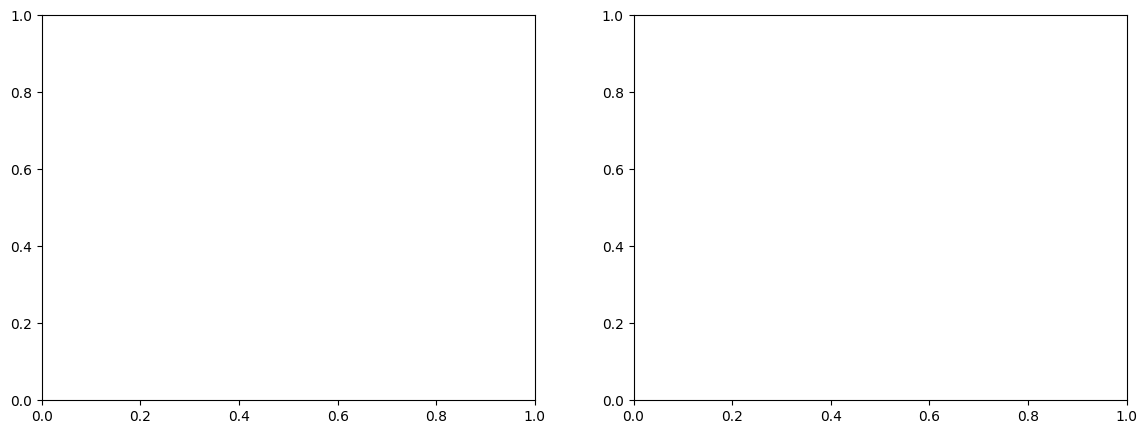

In [ ]:
# Plot SupCon training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history_supcon['train_loss'], label='Train Total', color='blue')
ax.plot(history_supcon['val_loss'], label='Val Total', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('SupCon Training: Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_supcon['ntxent'], label='NT-Xent (RC pairs)', color='green')
ax.plot(history_supcon['supcon'], label='SupCon (subclusters)', color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('SupCon Training: Loss Components')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("supcon_training_history.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: supcon_training_history.png")

## Step 14: Evaluate SupCon Embeddings

In [ ]:
# Load best SupCon model
# FIXED: PyTorch 2.6 requires weights_only=False, and checkpoint has 'model_state_dict' key
supcon_ckpt = torch.load(Path(".") / "supcon_best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(supcon_ckpt['model_state_dict'])
model.eval()

# Extract embeddings after SupCon training
supcon_embeddings, supcon_sf_ids, supcon_headers = extract_all_embeddings_with_subclusters(
    model=model,
    headers=headers,
    sequences=sequences,
    superfamilies=superfamilies,
    kmer_features=kmer_features,
    sf_to_id=sf_to_id,
    batch_size=BATCH_SIZE,
    device=DEVICE
)

print(f"SupCon embeddings: {supcon_embeddings.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'supcon_best.pt'

In [ ]:
# Evaluate clustering quality at both superfamily and subcluster levels

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

def evaluate_hierarchical_clustering(
    embeddings: np.ndarray,
    sf_ids: np.ndarray,
    subcluster_ids: np.ndarray,
    sf_names: List[str],
    subcluster_names: Dict[int, str]
):
    """Evaluate clustering at both superfamily and subcluster levels."""
    
    results = {}
    
    # 1. Superfamily-level evaluation (K-Means)
    n_sf = len(np.unique(sf_ids))
    kmeans_sf = KMeans(n_clusters=n_sf, random_state=42, n_init=10)
    pred_sf = kmeans_sf.fit_predict(embeddings)
    
    results['sf_silhouette'] = silhouette_score(embeddings, sf_ids)
    results['sf_kmeans_ari'] = adjusted_rand_score(sf_ids, pred_sf)
    results['sf_kmeans_nmi'] = normalized_mutual_info_score(sf_ids, pred_sf)
    
    # 2. Subcluster-level evaluation (K-Means)
    n_sub = len(np.unique(subcluster_ids))
    if n_sub > 1 and n_sub < len(embeddings):
        kmeans_sub = KMeans(n_clusters=min(n_sub, 500), random_state=42, n_init=10)
        pred_sub = kmeans_sub.fit_predict(embeddings)
        
        results['sub_silhouette'] = silhouette_score(embeddings, subcluster_ids)
        results['sub_kmeans_ari'] = adjusted_rand_score(subcluster_ids, pred_sub)
        results['sub_kmeans_nmi'] = normalized_mutual_info_score(subcluster_ids, pred_sub)
    else:
        results['sub_silhouette'] = 0
        results['sub_kmeans_ari'] = 0
        results['sub_kmeans_nmi'] = 0
    
    # 3. HDBSCAN for natural cluster discovery
    from sklearn.cluster import HDBSCAN
    hdb = HDBSCAN(min_cluster_size=20, min_samples=5)
    pred_hdb = hdb.fit_predict(embeddings)
    n_clusters_found = len(set(pred_hdb)) - (1 if -1 in pred_hdb else 0)
    noise_frac = (pred_hdb == -1).sum() / len(pred_hdb)
    
    results['hdbscan_clusters'] = n_clusters_found
    results['hdbscan_noise_frac'] = noise_frac
    
    # Filter out noise for metrics
    non_noise = pred_hdb >= 0
    if non_noise.sum() > 100:
        results['hdbscan_sf_ari'] = adjusted_rand_score(sf_ids[non_noise], pred_hdb[non_noise])
        results['hdbscan_sub_ari'] = adjusted_rand_score(subcluster_ids[non_noise], pred_hdb[non_noise])
    else:
        results['hdbscan_sf_ari'] = 0
        results['hdbscan_sub_ari'] = 0
    
    return results


# Evaluate before SupCon (contrastive only)
print("=" * 60)
print("Evaluation: Contrastive-Only Embeddings")
print("=" * 60)
eval_contrastive = evaluate_hierarchical_clustering(
    all_embeddings, all_sf_ids, subcluster_ids, sf_names, subcluster_names
)
for k, v in eval_contrastive.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n" + "=" * 60)
print("Evaluation: SupCon Embeddings")
print("=" * 60)
eval_supcon = evaluate_hierarchical_clustering(
    supcon_embeddings, supcon_sf_ids, subcluster_ids, sf_names, subcluster_names
)
for k, v in eval_supcon.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Comparison
print("\n" + "=" * 60)
print("IMPROVEMENT SUMMARY")
print("=" * 60)
for key in ['sf_silhouette', 'sf_kmeans_ari', 'sub_silhouette', 'sub_kmeans_ari']:
    diff = eval_supcon[key] - eval_contrastive[key]
    emoji = "✅" if diff > 0 else "❌"
    print(f"{emoji} {key}: {diff:+.4f} ({eval_contrastive[key]:.4f} → {eval_supcon[key]:.4f})")

Evaluation: Contrastive-Only Embeddings


NameError: name 'all_embeddings' is not defined

Computing UMAP for comparison plots...


NameError: name 'umap' is not defined

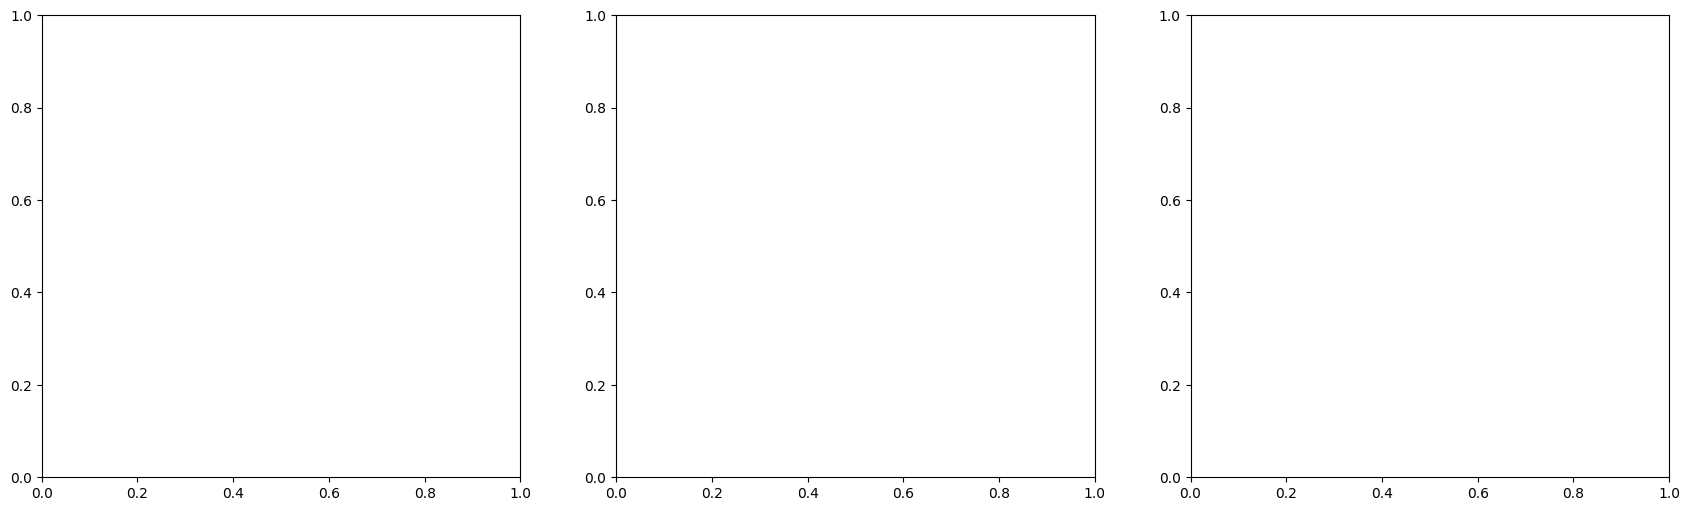

In [ ]:
# Final UMAP visualization comparing all three stages

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

print("Computing UMAP for comparison plots...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)

# Baseline (pre-contrastive)
umap_baseline = reducer.fit_transform(fused_baseline)

# Contrastive
umap_contrastive = reducer.fit_transform(all_embeddings)

# SupCon
umap_supcon = reducer.fit_transform(supcon_embeddings)

# Color by superfamily for all plots
unique_sfs = np.unique(all_sf_ids)
cmap = plt.cm.get_cmap('tab20', len(unique_sfs))

for ax_idx, (ax, coords, title) in enumerate(zip(
    axes,
    [umap_baseline, umap_contrastive, umap_supcon],
    ["Baseline (V4 frozen)", "Contrastive (NT-Xent)", "SupCon (NT-Xent + Subclusters)"]
)):
    for i, sf_id in enumerate(unique_sfs):
        # Handle different superfamily id arrays
        if ax_idx == 0:
            mask = sf_ids_baseline == sf_id
        else:
            mask = all_sf_ids == sf_id
        
        if mask.sum() > 0:
            ax.scatter(
                coords[mask, 0], 
                coords[mask, 1],
                c=[cmap(i)], 
                s=5, 
                alpha=0.5,
                label=sf_names[sf_id] if mask.sum() > 50 else None
            )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

# Add legend to last plot
axes[2].legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=6, markerscale=2)

plt.tight_layout()
plt.savefig("supcon_comparison_umap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: supcon_comparison_umap.png")

## Step 15: Save Final SupCon Model and Subcluster Assignments

In [ ]:
# Save everything

# 1. Final model with metadata
final_supcon_path = Path(".") / "supcon_final.pt"
torch.save({
    'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
    'history_contrastive': history,
    'history_supcon': history_supcon,
    'arch': arch,
    'sf_names': sf_names,
    'sf_to_id': sf_to_id,
    'subcluster_names': subcluster_names,
    'config': {
        'proj_dim': PROJ_DIM,
        'temperature': TEMPERATURE,
        'supcon_weight': SUPCON_WEIGHT,
        'lr': LR,
        'encoder_lr_mult': ENCODER_LR_MULT
    },
    'eval_contrastive': eval_contrastive,
    'eval_supcon': eval_supcon
}, final_supcon_path)
print(f"✓ Saved final model to {final_supcon_path}")

# 2. Embeddings with subcluster assignments
supcon_df = pd.DataFrame({
    'header': supcon_headers,
    'superfamily': [sf_names[i] for i in supcon_sf_ids],
    'sf_id': supcon_sf_ids,
    'subcluster_id': subcluster_ids,
    'subcluster_name': [subcluster_names[i] for i in subcluster_ids],
    **{f'embed_{i}': supcon_embeddings[:, i] for i in range(supcon_embeddings.shape[1])}
})
supcon_df.to_csv("supcon_embeddings_with_subclusters.csv", index=False)
print(f"✓ Saved embeddings to supcon_embeddings_with_subclusters.csv ({len(supcon_df)} rows)")

# 3. Subcluster summary
subcluster_summary = []
for sub_id, sub_name in subcluster_names.items():
    sf_name = sub_name.split("::")[0]
    count = (subcluster_ids == sub_id).sum()
    subcluster_summary.append({
        'subcluster_id': sub_id,
        'subcluster_name': sub_name,
        'superfamily': sf_name,
        'count': count
    })

subcluster_summary_df = pd.DataFrame(subcluster_summary)
subcluster_summary_df.to_csv("subcluster_summary.csv", index=False)
print(f"✓ Saved subcluster summary to subcluster_summary.csv ({len(subcluster_summary_df)} subclusters)")

# Print final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Total sequences: {len(supcon_headers)}")
print(f"Superfamilies: {len(sf_names)}")
print(f"Discovered subclusters: {len(subcluster_names)}")
print(f"Avg subclusters per superfamily: {len(subcluster_names) / len(sf_names):.2f}")
print(f"\nBest subcluster silhouette: {eval_supcon['sub_silhouette']:.4f}")
print(f"Best superfamily ARI: {eval_supcon['sf_kmeans_ari']:.4f}")

NameError: name 'history_supcon' is not defined